# MLP for anticorrelated weights

Sibling notebook to `MLP_for_correlated_weights.ipynb` -- same protocol, same real
AAV9-derived `F_viab`/`J_viab` (from `AAV9_profile_model.ipynb`), same `sequences`. Only
`F_sel`/`J_sel` differ: here they share the OPPOSITE trend from `F_viab`/`J_viab` (an amino
acid that's good for viability tends to be BAD for selectivity), via
`initialize_anticorrelated_weights` with `anticorrelation=0.2` (target correlation = -0.2,
only mildly anticorrelated).

## 0. Setup

In [62]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Must run before the first `import jax` anywhere -- same convention as DE_loopV1.ipynb /
# DEEPMLP_nnx_recovery.ipynb.

In [63]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

from flax import nnx
from functools import partial
from typing import Optional
import optax
from tqdm.auto import tqdm

from sequence_classesV1 import *
from analysisV1 import *
from initialize_weights import (
    load_F_viab_aav9_mlp, load_J_viab_aav9_mlp,
    initialize_correlated_weights, initialize_anticorrelated_weights, initialize_indep_weights,
    NUM_AMINO_ACIDS, NUM_POSITIONS,
)

print(f"JAX backend: {jax.default_backend()} -- devices: {jax.devices()}")

JAX backend: gpu -- devices: [CudaDevice(id=0)]


In [64]:
class ProfileMLP(nnx.Module):
    """
    MLP over the one-hot encoded per-position sequence (L=7 positions x A=20 amino acids
    -> 140 indicator features) -> scalar score. Same building blocks as SimpleMLP
    (Linear + BatchNorm + Dropout + gelu), with input_dim=L*A: one-hot gives the network
    the categorical amino-acid structure for free, so it only has to learn each position's
    per-amino-acid effect -- and any pairwise coupling -- on top of that, instead of also
    having to rediscover the categorical structure from a raw integer index.
    """

    def __init__(self, input_dim: int, hidden_dims: tuple[int, int] = (256, 128),
                 dropout_rate: float = 0.1, *, rngs: nnx.Rngs):
        h1, h2 = hidden_dims
        self.linear1    = nnx.Linear(input_dim, h1, rngs=rngs)
        self.batchnorm1 = nnx.BatchNorm(h1, use_running_average=False, rngs=rngs)
        self.dropout1   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear2    = nnx.Linear(h1, h2, rngs=rngs)
        self.batchnorm2 = nnx.BatchNorm(h2, use_running_average=False, rngs=rngs)
        self.dropout2   = nnx.Dropout(rate=dropout_rate, rngs=rngs)
        self.linear3    = nnx.Linear(h2, 1, rngs=rngs)

    def __call__(self, x: jax.Array, *, train: bool, rngs: Optional[nnx.Rngs] = None) -> jax.Array:
        x = self.linear1(x)
        x = self.batchnorm1(x, use_running_average=not train)
        x = self.dropout1(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        x = self.linear2(x)
        x = self.batchnorm2(x, use_running_average=not train)
        x = self.dropout2(x, deterministic=not train, rngs=rngs)
        x = nnx.gelu(x)

        return self.linear3(x).squeeze(-1)


In [65]:
@nnx.jit
def train_step(model, optimizer, x, y, rngs):
    """
    x : (batch, L*A) one-hot encoded per-position amino-acid indicators
    y : (batch,) target log enrichment
    """
    def loss_fn(model, rngs):
        y_pred = model(x, train=True, rngs=rngs)
        return jnp.mean((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model, rngs)
    optimizer.update(model, grads)
    return loss


@nnx.jit
def eval_step(model, x, y):
    y_pred = model(x, train=False)
    return jnp.mean((y_pred - y) ** 2)


@nnx.scan(in_axes=(nnx.Carry, 0, 0), out_axes=(nnx.Carry, 0))
def train_epoch_scan(carry, xb, yb):
    """Fuses one epoch's mini-batch train_step calls into a single compiled nnx.scan
    instead of a Python for-loop issuing one XLA dispatch per batch."""
    model, optimizer, rngs = carry
    loss = train_step(model, optimizer, xb, yb, rngs)
    return (model, optimizer, rngs), loss


In [66]:
def train_profile_mlp(X_train, y_train, X_val, y_val, hidden_dims=(128, 64),
                       dropout_rate=0.1, epochs=300, batch_size=256,
                       peak_lr=1e-3, final_lr=1e-5, weight_decay=0,
                       patience=20, seed=0, verbose=True, model=None):
    """
    model : optional existing ProfileMLP to continue training from (warm start) instead of
    initializing a fresh one.
    """
    rngs = nnx.Rngs(seed)
    if model is None:
        model = ProfileMLP(input_dim=X_train.shape[1], hidden_dims=hidden_dims,
                            dropout_rate=dropout_rate, rngs=rngs)

    n_train         = X_train.shape[0]
    steps_per_epoch = max(n_train // batch_size, 1)
    total_steps     = steps_per_epoch * epochs

    lr_schedule_fn = optax.warmup_cosine_decay_schedule(
        init_value=0., peak_value=peak_lr,
        warmup_steps=int(total_steps * 0.1),
        decay_steps=int(total_steps * 0.9),
        end_value=final_lr,
    )
    optimizer = nnx.Optimizer(
        model, optax.adamw(learning_rate=lr_schedule_fn, weight_decay=weight_decay), wrt=nnx.Param
    )

    X_train, y_train = jnp.asarray(X_train), jnp.asarray(y_train)
    X_val,   y_val   = jnp.asarray(X_val),   jnp.asarray(y_val)

    shuffle_key = jax.random.key(seed)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in tqdm(range(epochs), desc="Training ProfileMLP", disable=not verbose):
        shuffle_key, perm_key = jax.random.split(shuffle_key)
        perm      = jax.random.permutation(perm_key, n_train)
        batch_idx = perm[: steps_per_epoch * batch_size].reshape(steps_per_epoch, batch_size)

        (model, optimizer, rngs), step_losses = train_epoch_scan(
            (model, optimizer, rngs), X_train[batch_idx], y_train[batch_idx]
        )
        train_loss = float(jnp.mean(step_losses))
        val_loss   = float(eval_step(model, X_val, y_val))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val, bad_epochs = val_loss, 0
            best_state = nnx.state(model)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val MSE={best_val:.4f})")
                break

    nnx.update(model, best_state)
    return model, history


## Part 1 — Build the protocol with realistic weights as in `AAV9_profile_model.ipynb`

`AAV9_profile_model.ipynb` (`Modelization_V1/MLP_regression/AAV_viability_test/`) trains a
small MLP (`ProfileMLP`: one-hot per-position sequence -> 2 hidden layers -> scalar score) on
`aav9.csv`, 68,776 real AAV9 capsid variants with a measured log-enrichment `target`. Two
things get pulled out of that trained network afterward:

- `F_viab` — a `(num_amino_acids=20, num_positions=7)` profile, from a SINGLE-mutant scan:
  for a batch of real background sequences, flip one position at a time and see how the
  model's predicted score shifts.
- `J_viab` — a `(7, 7, 20, 20)` pairwise coupling, from the same idea extended to a
  DOUBLE-mutant scan (flip two positions at once).

Both are exported to `.npy` (gitignored, a derived artifact) and loaded here via
`initialize_weights.py` — see that notebook for the full training/extraction code and
diagnostics (naive-vs-MLP agreement, etc.); this notebook starts from the result and treats
`F_viab`/`J_viab` as "ground truth" for what a REAL viability landscape looks like.

F_viab shape: (20, 7)
J_viab shape: (7, 7, 20, 20)


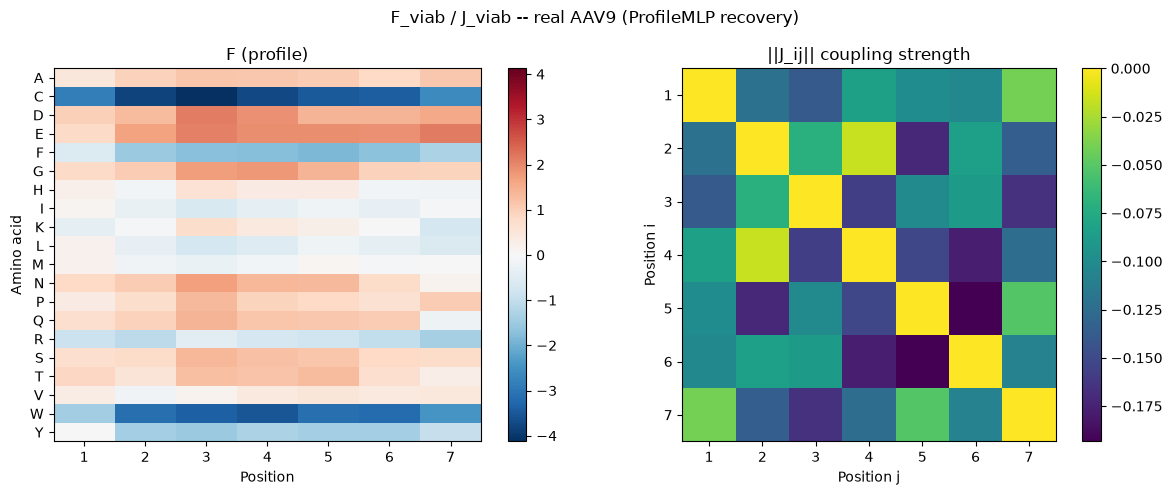

In [67]:
F_viab = load_F_viab_aav9_mlp()
J_viab = load_J_viab_aav9_mlp()

print(f"F_viab shape: {F_viab.shape}")
print(f"J_viab shape: {J_viab.shape}")

_ = plot_teacher_weights(F_viab, J_viab, title="F_viab / J_viab -- real AAV9 (ProfileMLP recovery)")
plt.show()

## 1. Recovery by MLP with anticorrelated weights 

In [68]:
anticorrelation = 0.2

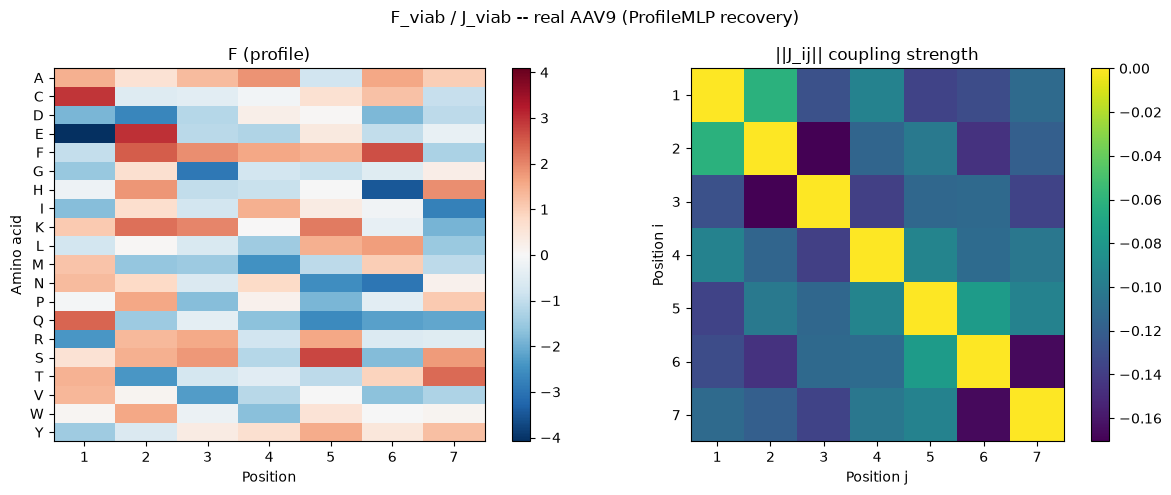

In [69]:
F_sel_anti, J_sel_anti = initialize_anticorrelated_weights(jax.random.key(10), F_viab, J_viab, anticorrelation)
_ = plot_teacher_weights(F_sel_anti, J_sel_anti, title="F_viab / J_viab -- real AAV9 (ProfileMLP recovery)")
plt.show()

In [70]:
key = jax.random.key(0)
key, k_seq = jax.random.split(key)

N = 20_000
sequences = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_anti = ProtocolV3(N0=1_000_000_000, N1=500_000_000, 
        dilution_factor=10, sequences=sequences, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

In [71]:
def compare_F(F_viab, F_sel, title, label_a="F_viab", label_b="F_sel"):
    """Same 3-panel recipe as AAV9_profile_model.ipynb's F comparisons: two heatmaps
    (shared RdBu_r scale) + a raw-entry scatter with Pearson r."""
    F_viab, F_sel = np.asarray(F_viab), np.asarray(F_sel)
    vmax = max(np.abs(F_viab).max(), np.abs(F_sel).max())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, F, panel_title in [(axes[0], F_viab, label_a), (axes[1], F_sel, label_b)]:
        im = ax.imshow(F, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(panel_title)
        ax.set_xlabel("Position"); ax.set_ylabel("Amino acid")
        ax.set_xticks(range(NUM_POSITIONS)); ax.set_xticklabels(range(1, NUM_POSITIONS + 1))
        ax.set_yticks(range(NUM_AMINO_ACIDS)); ax.set_yticklabels(AA_LABELS)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    r = pearson(F_viab.ravel(), F_sel.ravel())
    axes[2].scatter(F_viab.ravel(), F_sel.ravel(), s=14, alpha=0.6)
    lims = [min(F_viab.min(), F_sel.min()), max(F_viab.max(), F_sel.max())]
    axes[2].plot(lims, lims, "k--", alpha=0.5)
    axes[2].set_xlabel(label_a); axes[2].set_ylabel(label_b)
    axes[2].set_title(f"Pearson r = {r:.3f}")

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def run_and_summarize(name, protocol):
    """Shows F_sel vs F_viab for this protocol's regime, runs one loop_DE() round, and plots
    viability-vs-selectivity score colored by abundance at every pipeline stage
    (plot_all_lambda_scores). Returns a one-row summary dict."""
    compare_F(F_viab, protocol.F_sel, f"{name} -- F_sel vs F_viab")

    viab_scores = np.array(protocol.compute_score(protocol.F_viab, protocol.J_viab))
    sel_scores  = np.array(protocol.compute_score(protocol.F_sel,  protocol.J_sel))
    score_corr  = pearson(viab_scores, sel_scores)
    p10         = precision_at_k(viab_scores, sel_scores, k_frac=0.10)

    protocol.loop_DE()
    lambda4 = np.array(protocol.lambda4)

    _ = plot_all_lambda_scores(protocol, title=f"{name} -- viability vs selectivity score, by pipeline stage")
    plt.show()

    return dict(regime=name, score_corr=score_corr, top10pct_overlap=p10,
                surviving=int((lambda4 > 0).sum()), pct_surviving=100 * (lambda4 > 0).mean(),
                entropy=shannon_entropy(lambda4))

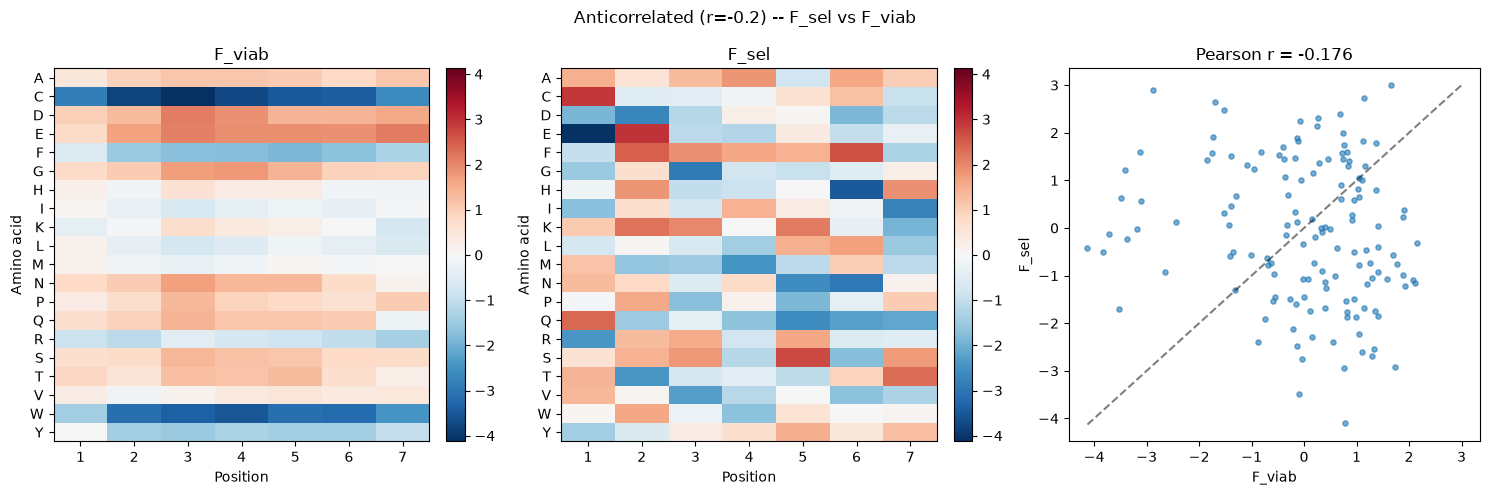

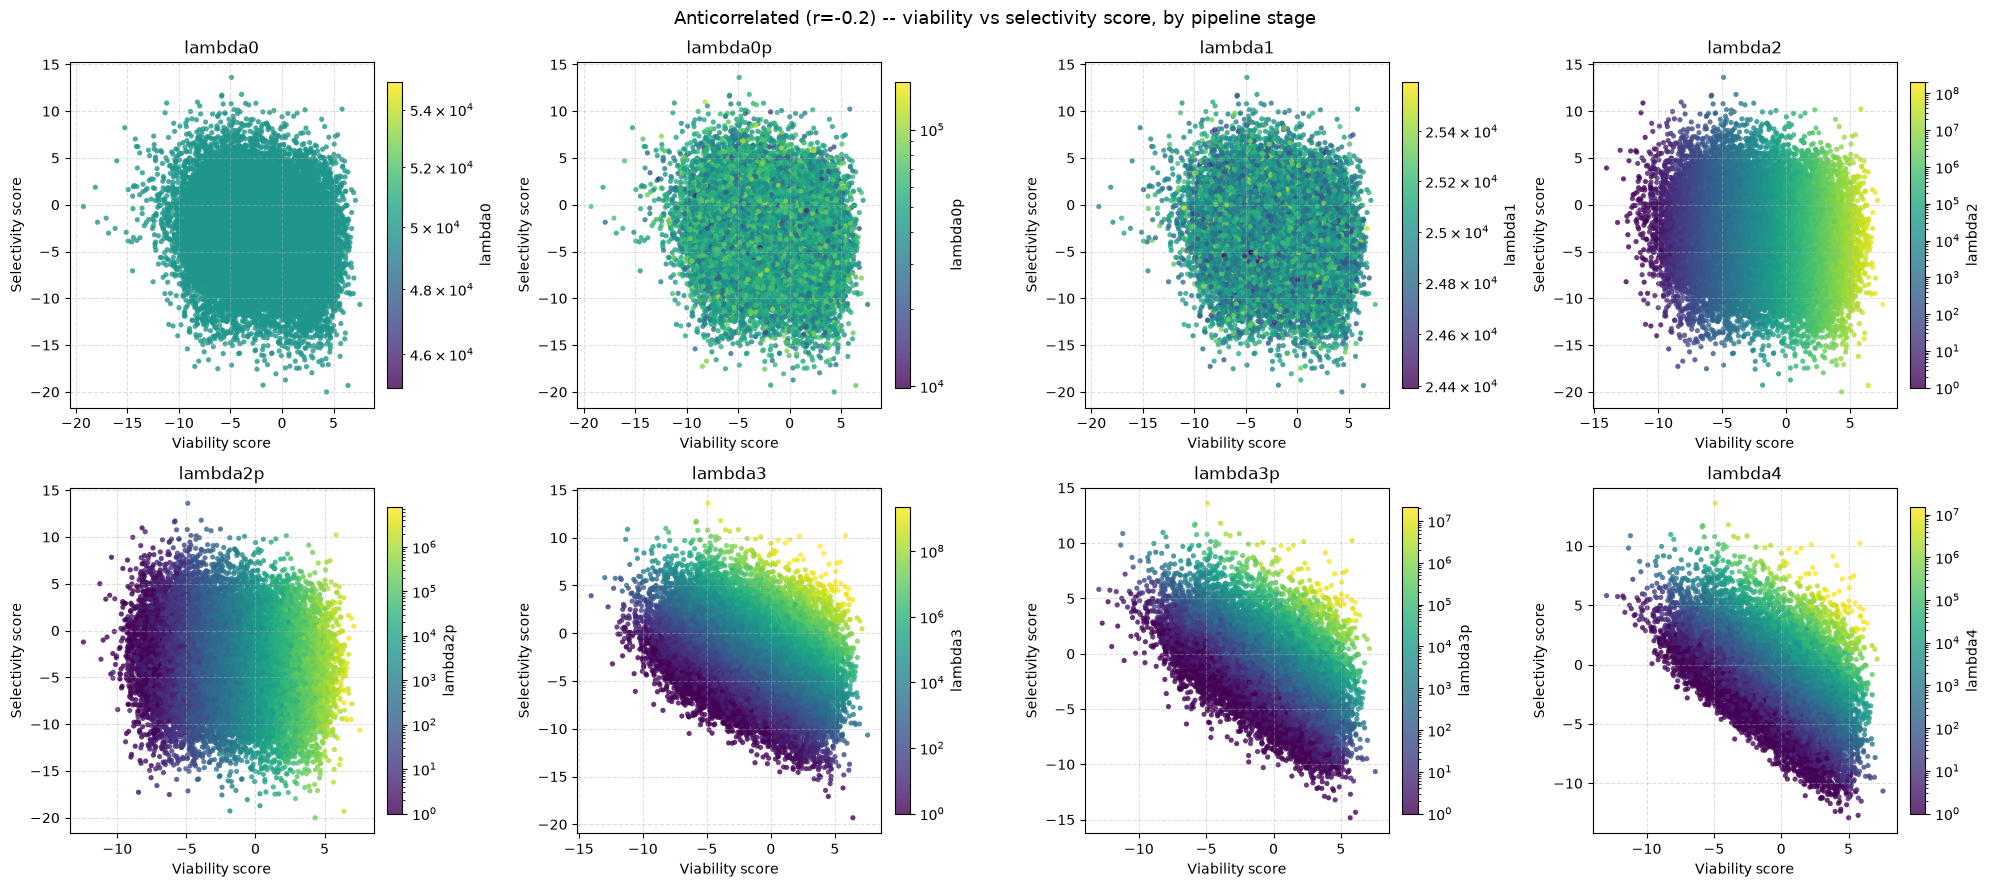

{'regime': 'Anticorrelated (r=-0.2)',
 'score_corr': -0.16663621121013109,
 'top10pct_overlap': 0.0605,
 'surviving': 11898,
 'pct_surviving': np.float64(59.489999999999995),
 'entropy': 5.430357676314862}

In [72]:
summary_anti = run_and_summarize(f"Anticorrelated (r=-{anticorrelation})", protocol_anti)
summary_anti

In [73]:
def lambda_evolution_table(protocol, n_rounds=1):
    """
    Runs protocol.N_loop_DE(n_rounds) and tabulates total abundance + surviving diversity for
    every lambda checkpoint, in true pipeline order, one column group per round.
    """
    rounds = protocol.N_loop_DE(n_rounds)
    stages = ["lambda0", "lambda0p", "lambda1", "lambda2", "lambda2p", "lambda3", "lambda3p", "lambda4"]

    rows = []
    for round_idx, (bio_row, ngs_row) in enumerate(rounds):
        lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
        lambda0p, lambda2p, lambda3p = ngs_row
        stage_arrays = {
            "lambda0": lambda0, "lambda0p": lambda0p, "lambda1": lambda1,
            "lambda2": lambda2, "lambda2p": lambda2p, "lambda3": lambda3,
            "lambda3p": lambda3p, "lambda4": lambda4,
        }
        for stage in stages:
            arr = np.asarray(stage_arrays[stage])
            rows.append(dict(
                round=round_idx, stage=stage,
                total=float(arr.sum()), n_surviving=int((arr > 0).sum()),
            ))

    df = pd.DataFrame(rows)
    df["pct_surviving"] = 100 * df["n_surviving"] / protocol.d0
    return df.pivot(index="stage", columns="round", values=["total", "n_surviving", "pct_surviving"]).reindex(stages)

lambda_evolution_table(protocol_anti, n_rounds=1)

Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  3.02it/s]


,total,n_surviving,pct_surviving
round,0,0,0
stage,,,
lambda0,1.000000e+09,20000.0,100.000
lambda0p,1.000870e+09,20000.0,100.000
lambda1,4.999818e+08,20000.0,100.000
lambda2,2.546196e+10,19909.0,99.545
lambda2p,9.918714e+08,18877.0,94.385
lambda3,1.456337e+11,17514.0,87.570
lambda3p,1.009355e+09,11943.0,59.715
lambda4,1.000036e+09,11878.0,59.390


In [74]:
rounds = protocol_anti.N_loop_DE(1)
bio_row, ngs_row = rounds[0]
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

lambda1 = np.asarray(lambda1)
lambda2 = np.asarray(lambda2)
lambda3 = np.asarray(lambda3)

eps = 1.0  # pseudocount of 1 read -- avoids log(0) and matches the floor of the real
           # AAV9 log-enrichment scale (aav9.csv 'target' ranges ~[-12, 7.5])

log_enr_viab = np.log((lambda2 + eps) / (lambda1 + eps))  # target1 -- viability phase
log_enr_sel  = np.log((lambda3 + eps) / (lambda2 + eps))  # target2 -- selectivity phase

print(f"log_enr_viab: min={log_enr_viab.min():.2f}  max={log_enr_viab.max():.2f}  mean={log_enr_viab.mean():.2f}")
print(f"log_enr_sel : min={log_enr_sel.min():.2f}  max={log_enr_sel.max():.2f}  mean={log_enr_sel.mean():.2f}")

Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.68it/s]

log_enr_viab: min=-10.14  max=9.03  mean=-0.87
log_enr_sel : min=-17.92  max=13.63  mean=-2.90


## Export to CSV (cached per experiment parameters)

Filename encodes the diversity and the parameters that change the resulting distribution
(`T_sel`, `T_viab`, `noise`) -- e.g. `diversite20000_Tsel1_Tviab1_noise05.csv` for
`d0=20_000`, `T_sel=1`, `T_viab=1`, `noise_viab=noise_sel=0.5`. If that exact file already
exists on disk it's loaded instead of re-running the (slow) simulation.

In [75]:
def dataset_filename(protocol, label):
    def fmt(v):
        return f"{float(v):g}".replace(".", "")

    if protocol.noise_viab == protocol.noise_sel:
        noise_part = f"noise{fmt(protocol.noise_viab)}"
    else:
        noise_part = f"noiseviab{fmt(protocol.noise_viab)}_noisesel{fmt(protocol.noise_sel)}"

    return (f"diversity{protocol.d0}_Tsel{fmt(protocol._T_sel)}"
            f"_Tviab{fmt(protocol._T_viab)}_{noise_part}_{label}.csv")


def build_or_load_dataset(protocol, sequences, log_enr_viab, log_enr_sel, label):
    """(sequence, target1=viability log-enrichment, target2=selectivity log-enrichment)
    dataset for this protocol's parameters. `label` distinguishes the F_sel/J_sel flavor
    (correlated/anticorrelated/indep) so the three sibling notebooks -- which otherwise share
    the same diversity/T_sel/T_viab/noise parameters -- don't collide on the same CSV. Loads
    the CSV from disk if it was already generated for this exact (diversity, T_sel, T_viab,
    noise, label) combination, else builds and saves it."""
    path = dataset_filename(protocol, label)
    if os.path.exists(path):
        print(f"{path} already exists -- loading from disk")
        return pd.read_csv(path)

    seq_strings = ["".join(AA_LABELS[a] for a in row) for row in np.asarray(sequences)]
    df = pd.DataFrame({"sequence": seq_strings, "target1": log_enr_viab, "target2": log_enr_sel})
    df.to_csv(path, index=False)
    print(f"saved {path} ({len(df)} rows)")
    return df


dataset_anti = build_or_load_dataset(protocol_anti, sequences, log_enr_viab, log_enr_sel, label="ac")
dataset_anti.head()

diversity20000_Tsel1_Tviab1_noise05_ac.csv already exists -- loading from disk


,sequence,target1,target2
0,DDTSNIP,4.790522,-7.686602
1,MSTDFNG,3.657291,1.142704
2,CQNSWCF,-3.332847,-3.571221
3,CRCHSEA,-6.730421,2.143980
4,QAFNMTQ,0.394225,1.879594


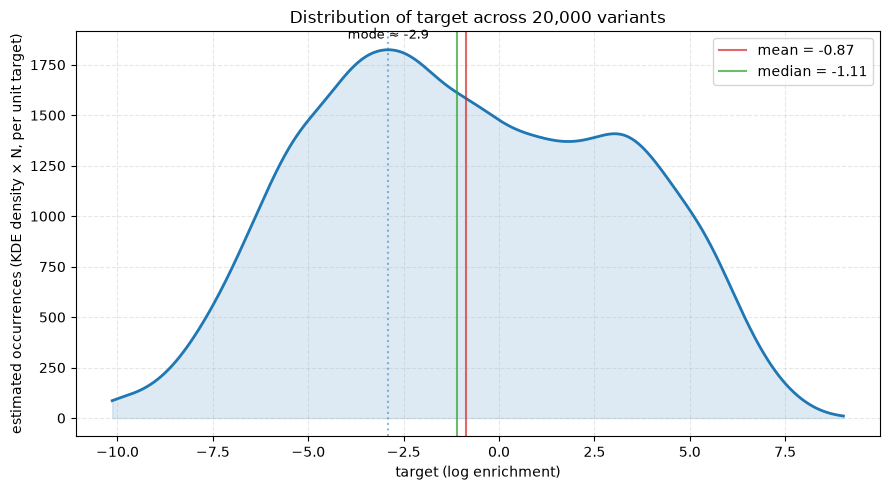

detected mode(s) at target ≈ [-2.91]


In [76]:
t_viab = dataset_anti["target1"].to_numpy()

# Smooth density (Gaussian KDE), not a binned histogram -- rescaled by N so the curve reads
# as an estimated occurrence count per unit of target (area under the curve over a range ~=
# expected number of variants in that range), rather than a probability density.
grid = np.linspace(t_viab.min(), t_viab.max(), 1000)
kde = gaussian_kde(t_viab, bw_method=0.15)
occurrences = kde(grid) * len(t_viab)

# Auto-detect modes (and, if bimodal, the valley between them) instead of eyeballing the plot.
peaks, _ = find_peaks(occurrences, prominence=occurrences.max() * 0.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grid, occurrences, color="tab:blue", lw=2)
ax.fill_between(grid, occurrences, alpha=0.15, color="tab:blue")

for p in peaks:
    ax.axvline(grid[p], color="tab:blue", linestyle=":", alpha=0.5)
    ax.annotate(f"mode ≈ {grid[p]:.1f}", (grid[p], occurrences[p]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

if len(peaks) >= 2:
    lo, hi = peaks[0], peaks[-1]
    valley = lo + np.argmin(occurrences[lo:hi + 1])
    ax.axvline(grid[valley], color="gray", linestyle="--", alpha=0.6)
    ax.annotate(f"valley ≈ {grid[valley]:.1f}", (grid[valley], occurrences[valley]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="gray")

ax.axvline(t_viab.mean(), color="tab:red", linestyle="-", alpha=0.7, label=f"mean = {t_viab.mean():.2f}")
ax.axvline(np.median(t_viab), color="tab:green", linestyle="-", alpha=0.7, label=f"median = {np.median(t_viab):.2f}")

ax.set_xlabel("target (log enrichment)")
ax.set_ylabel("estimated occurrences (KDE density × N, per unit target)")
ax.set_title(f"Distribution of target across {len(t_viab):,} variants")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"detected mode(s) at target ≈ {np.round(grid[peaks], 2)}")


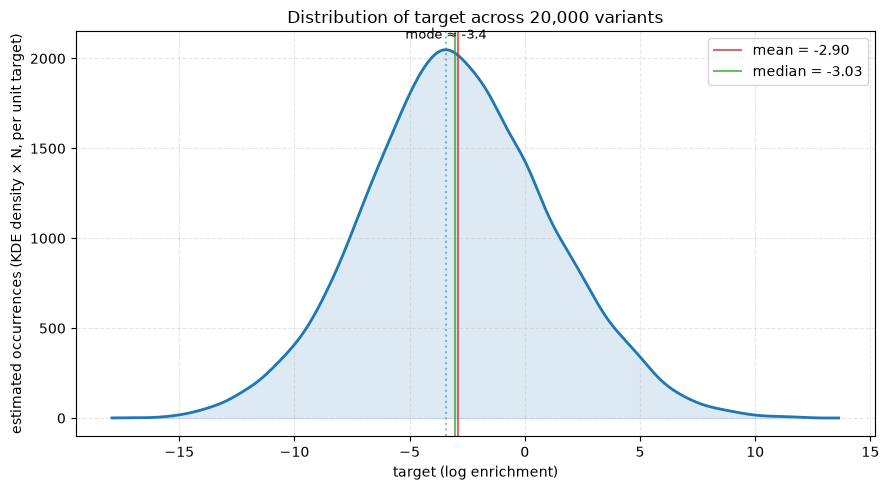

detected mode(s) at target ≈ [-3.42]


In [77]:
t_sel = dataset_anti["target2"].to_numpy()

# Smooth density (Gaussian KDE), not a binned histogram -- rescaled by N so the curve reads
# as an estimated occurrence count per unit of target (area under the curve over a range ~=
# expected number of variants in that range), rather than a probability density.
grid = np.linspace(t_sel.min(), t_sel.max(), 1000)
kde = gaussian_kde(t_sel, bw_method=0.15)
occurrences = kde(grid) * len(t_sel)

# Auto-detect modes (and, if bimodal, the valley between them) instead of eyeballing the plot.
peaks, _ = find_peaks(occurrences, prominence=occurrences.max() * 0.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grid, occurrences, color="tab:blue", lw=2)
ax.fill_between(grid, occurrences, alpha=0.15, color="tab:blue")

for p in peaks:
    ax.axvline(grid[p], color="tab:blue", linestyle=":", alpha=0.5)
    ax.annotate(f"mode ≈ {grid[p]:.1f}", (grid[p], occurrences[p]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

if len(peaks) >= 2:
    lo, hi = peaks[0], peaks[-1]
    valley = lo + np.argmin(occurrences[lo:hi + 1])
    ax.axvline(grid[valley], color="gray", linestyle="--", alpha=0.6)
    ax.annotate(f"valley ≈ {grid[valley]:.1f}", (grid[valley], occurrences[valley]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="gray")

ax.axvline(t_sel.mean(), color="tab:red", linestyle="-", alpha=0.7, label=f"mean = {t_sel.mean():.2f}")
ax.axvline(np.median(t_sel), color="tab:green", linestyle="-", alpha=0.7, label=f"median = {np.median(t_sel):.2f}")

ax.set_xlabel("target (log enrichment)")
ax.set_ylabel("estimated occurrences (KDE density × N, per unit target)")
ax.set_title(f"Distribution of target across {len(t_sel):,} variants")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"detected mode(s) at target ≈ {np.round(grid[peaks], 2)}")


## ProfileMLP recovery: predicting log-enrichment from sequence, retrieving F

Same recipe as `AAV9_profile_model.ipynb` (`ProfileMLP` + `train_profile_mlp`, already defined
in Setup above), applied here to `dataset_anti` (the simulated CSV) instead of the real
`aav9.csv`: one `ProfileMLP` instance trained on `target1` (viability log-enrichment) and one
trained on `target2` (selectivity log-enrichment), then `F_viab_hat`/`F_sel_hat` pulled back out
via a single-mutant scan and compared against the ground-truth `F_viab`/`F_sel_anti` used to
generate the data -- plus top-k recovery plots showing how well each model ranks the actual
best variants on held-out data.

In [78]:
def split_train_val(X, y, val_frac=0.15, seed=0):
    rng   = np.random.default_rng(seed)
    idx   = rng.permutation(len(X))
    n_val = int(len(X) * val_frac)
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]


@nnx.jit
def predict_scores(model, x):
    return model(x, train=False)


### ------------ Sequence string -> raw indices -> one-hot ------------ ###
lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes  = np.frombuffer("".join(dataset_anti["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(dataset_anti), NUM_POSITIONS)
seq_oh     = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix].reshape(len(dataset_anti), -1)

y_viab_all = dataset_anti["target1"].to_numpy()
y_sel_all  = dataset_anti["target2"].to_numpy()

idx_train, idx_test = train_test_split(np.arange(len(dataset_anti)), test_size=0.5, random_state=0)
X_train_full, X_test = seq_oh[idx_train], seq_oh[idx_test]

print(f"X_train_full shape: {X_train_full.shape}  X_test shape: {X_test.shape}")

X_train_full shape: (10000, 140)  X_test shape: (10000, 140)


In [79]:
y_viab_train, y_viab_test = y_viab_all[idx_train], y_viab_all[idx_test]
Xtr_viab, ytr_viab, Xva_viab, yva_viab = split_train_val(X_train_full, y_viab_train, val_frac=0.15, seed=0)
print(f"ProfileMLP (viab) -- train: {len(Xtr_viab):,}  val: {len(Xva_viab):,}  test: {len(X_test):,}")

model_viab, hist_viab = train_profile_mlp(Xtr_viab, ytr_viab, Xva_viab, yva_viab, seed=0)

ProfileMLP (viab) -- train: 8,500  val: 1,500  test: 10,000


Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]

Training ProfileMLP:  62%|██████▏   | 185/300 [00:02<00:01, 61.75it/s]

Early stopping at epoch 185 (best val MSE=0.5471)


In [80]:
y_sel_train, y_sel_test = y_sel_all[idx_train], y_sel_all[idx_test]
Xtr_sel, ytr_sel, Xva_sel, yva_sel = split_train_val(X_train_full, y_sel_train, val_frac=0.15, seed=1)
print(f"ProfileMLP (sel) -- train: {len(Xtr_sel):,}  val: {len(Xva_sel):,}  test: {len(X_test):,}")

model_sel, hist_sel = train_profile_mlp(Xtr_sel, ytr_sel, Xva_sel, yva_sel, seed=1)

ProfileMLP (sel) -- train: 8,500  val: 1,500  test: 10,000


Training ProfileMLP:   0%|          | 0/300 [00:00<?, ?it/s]

Training ProfileMLP:  47%|████▋     | 141/300 [00:02<00:02, 59.08it/s]

Early stopping at epoch 141 (best val MSE=2.3199)


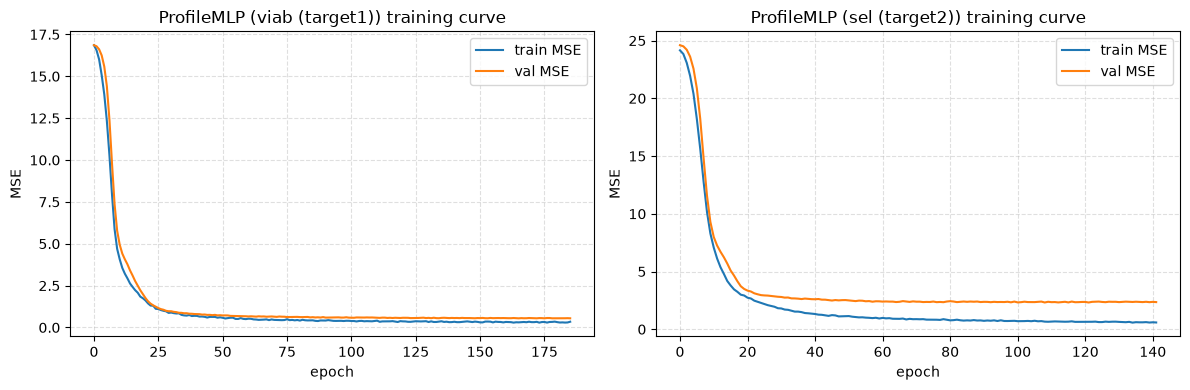

target1 (viab) -- Pearson r (test): 0.9829
target2 (sel)  -- Pearson r (test): 0.9212


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, name in [(axes[0], hist_viab, "viab (target1)"), (axes[1], hist_sel, "sel (target2)")]:
    ax.plot(hist["train_loss"], label="train MSE")
    ax.plot(hist["val_loss"],   label="val MSE")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
    ax.set_title(f"ProfileMLP ({name}) training curve")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

pred_viab_test = np.asarray(predict_scores(model_viab, jnp.asarray(X_test)))
pred_sel_test  = np.asarray(predict_scores(model_sel,  jnp.asarray(X_test)))

print(f"target1 (viab) -- Pearson r (test): {pearson(y_viab_test, pred_viab_test):.4f}")
print(f"target2 (sel)  -- Pearson r (test): {pearson(y_sel_test,  pred_sel_test):.4f}")

In [82]:
def extract_effective_F(model, backgrounds, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS, batch_size=8192):
    """
    Single-mutant scan against background sequences: for a background s and mutation p->a,
    M(s^{p->a}) - M(s) isolates f_p(a) only up to terms that depend on s's other positions.
    Averaged over many backgrounds, F is recovered up to a global additive constant. Same
    recipe as AAV9_profile_model.ipynb's extract_effective_F.
    """
    backgrounds = np.asarray(backgrounds, dtype=np.int64)
    M = backgrounds.shape[0]

    n_single       = M * L * A
    single_mutants = np.repeat(backgrounds, L * A, axis=0)
    pos_pattern    = np.tile(np.repeat(np.arange(L), A), M)
    aa_pattern     = np.tile(np.tile(np.arange(A), L), M)
    single_mutants[np.arange(n_single), pos_pattern] = aa_pattern

    x_all    = np.concatenate([backgrounds, single_mutants], axis=0)              # (n, L) raw indices
    x_all_oh = np.eye(A, dtype=np.float32)[x_all].reshape(x_all.shape[0], -1)     # (n, L*A) one-hot

    scores_chunks = []
    for start in range(0, x_all_oh.shape[0], batch_size):
        chunk = jnp.asarray(x_all_oh[start : start + batch_size])
        scores_chunks.append(np.asarray(predict_scores(model, chunk)))
    scores = np.concatenate(scores_chunks)

    mean_score    = scores.mean()
    single_scores = scores[M:].reshape(M, L, A)

    F_flat = single_scores.mean(axis=0) - mean_score  # (L, A)
    return F_flat.T.astype(np.float32)                # (A, L)


rng_bg        = np.random.default_rng(0)
M_backgrounds = 256
bg_idx        = rng_bg.choice(seq_matrix.shape[0], size=M_backgrounds, replace=False)
backgrounds   = seq_matrix[bg_idx]

F_viab_hat = extract_effective_F(model_viab, backgrounds)
F_sel_hat  = extract_effective_F(model_sel,  backgrounds)

print(f"F_viab_hat shape: {F_viab_hat.shape}  F_sel_hat shape: {F_sel_hat.shape}")

F_viab_hat shape: (20, 7)  F_sel_hat shape: (20, 7)


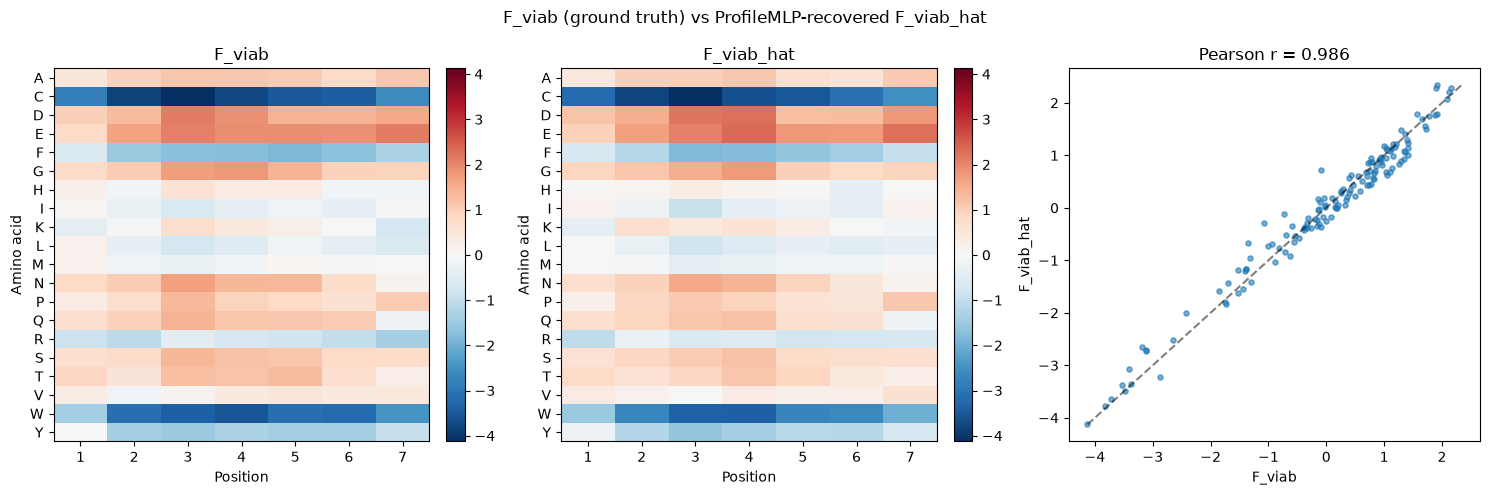

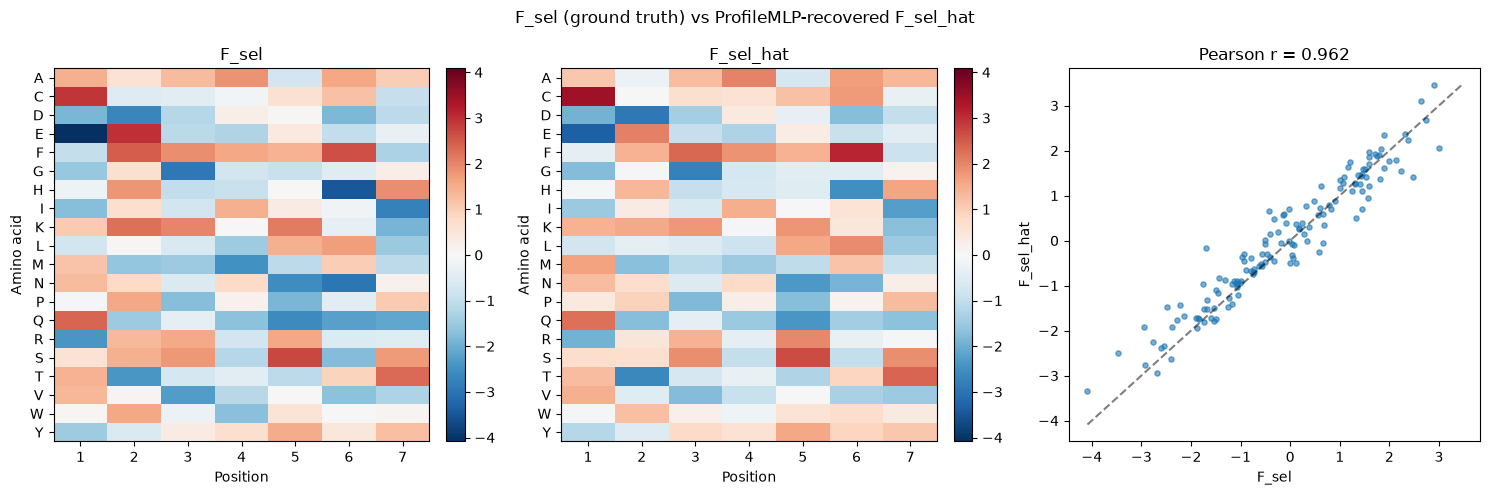

In [83]:
compare_F(F_viab, F_viab_hat, "F_viab (ground truth) vs ProfileMLP-recovered F_viab_hat",
          label_a="F_viab", label_b="F_viab_hat")
compare_F(F_sel_anti, F_sel_hat, "F_sel (ground truth) vs ProfileMLP-recovered F_sel_hat",
          label_a="F_sel", label_b="F_sel_hat")

### How well are the best variants predicted? (held-out top-k recovery)

Held-out (test) top-k recovery -- viability (target1):
  Top   1%   precision = 0.600   (random baseline = 0.010)
  Top   5%   precision = 0.770   (random baseline = 0.050)
  Top  10%   precision = 0.851   (random baseline = 0.100)
  Top  20%   precision = 0.916   (random baseline = 0.200)


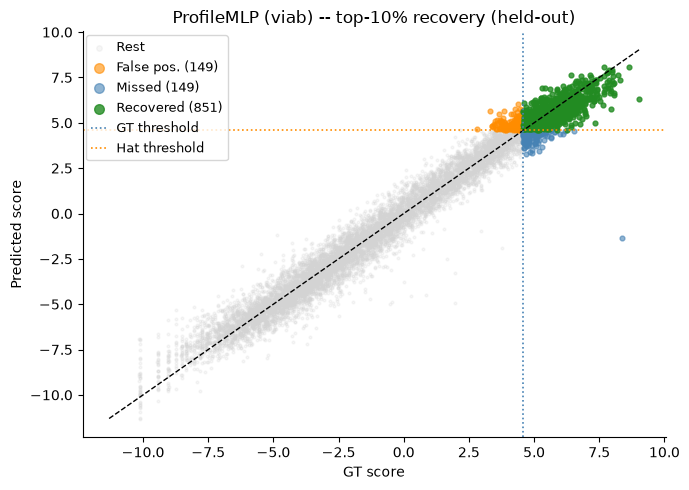


Held-out (test) top-k recovery -- selectivity (target2):
  Top   1%   precision = 0.570   (random baseline = 0.010)
  Top   5%   precision = 0.672   (random baseline = 0.050)
  Top  10%   precision = 0.749   (random baseline = 0.100)
  Top  20%   precision = 0.802   (random baseline = 0.200)


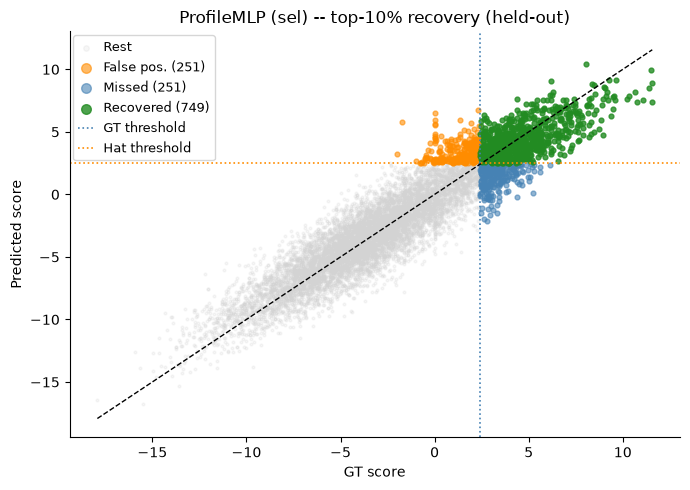

In [84]:
print("Held-out (test) top-k recovery -- viability (target1):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_viab_test, pred_viab_test, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_viab_test, pred_viab_test, k_frac=0.10,
                          title="ProfileMLP (viab) -- top-10% recovery (held-out)")
plt.show()

print("\nHeld-out (test) top-k recovery -- selectivity (target2):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_sel_test, pred_sel_test, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_sel_test, pred_sel_test, k_frac=0.10,
                          title="ProfileMLP (sel) -- top-10% recovery (held-out)")
plt.show()

### On a another dataset

In [85]:
key = jax.random.key(42)
key, k_seq = jax.random.split(key)

N = 2_000_000
sequences2 = jax.random.randint(k_seq, shape=(N, NUM_POSITIONS), minval=0, maxval=NUM_AMINO_ACIDS)

protocol_anti2 = ProtocolV3(N0=1_000_000_000, N1=500_000_000, 
        dilution_factor=10, sequences=sequences2, D=1e9,
        F_viab=F_viab, J_viab=J_viab, F_sel=F_sel_anti, J_sel=J_sel_anti,
        noise_viab=0.5, noise_sel=0.5, T_sel=1, T_viab=1,
        )

In [86]:
rounds = protocol_anti2.N_loop_DE(1)
bio_row, ngs_row = rounds[0]
lambda0, lambda1, lambda2, lambda3, lambda4 = bio_row
lambda0p, lambda2p, lambda3p = ngs_row

lambda1 = np.asarray(lambda1)
lambda2 = np.asarray(lambda2)
lambda3 = np.asarray(lambda3)
lambda1_big, lambda2_big, lambda3_big = lambda1, lambda2, lambda3  # keep distinct names for later reference

eps = 1.0  # pseudocount of 1 read -- avoids log(0) and matches the floor of the real
           # AAV9 log-enrichment scale (aav9.csv 'target' ranges ~[-12, 7.5])

log_enr_viab = np.log((lambda2 + eps) / (lambda1 + eps))  # target1 -- viability phase
log_enr_sel  = np.log((lambda3 + eps) / (lambda2 + eps))  # target2 -- selectivity phase

print(f"log_enr_viab: min={log_enr_viab.min():.2f}  max={log_enr_viab.max():.2f}  mean={log_enr_viab.mean():.2f}")
print(f"log_enr_sel : min={log_enr_sel.min():.2f}  max={log_enr_sel.max():.2f}  mean={log_enr_sel.mean():.2f}")

Directed evolution rounds: 100%|██████████| 1/1 [00:01<00:00,  1.32s/it]

log_enr_viab: min=-5.79  max=15.89  mean=-4.17
log_enr_sel : min=-16.60  max=15.78  mean=-0.50


In [87]:
dataset_anti2 = build_or_load_dataset(protocol_anti2, sequences2, log_enr_viab, log_enr_sel, label="ac")
dataset_anti2.head()

diversity2000000_Tsel1_Tviab1_noise05_ac.csv already exists -- loading from disk


,sequence,target1,target2
0,GPFPSFC,-1.950661,7.413307
1,WTSATKN,-5.631212,0.000000
2,QKCDGIY,-5.365976,0.000000
3,WHAWFWW,-5.568345,0.000000
4,HQWMAEI,-5.468060,0.000000


In [88]:
### No retraining here -- model_viab/model_sel are the SAME models trained earlier on the
### 20,000-variant dataset. This just encodes the 200,000 new sequences and runs inference.
seq_bytes2  = np.frombuffer("".join(dataset_anti2["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix2 = lut[seq_bytes2].reshape(len(dataset_anti2), NUM_POSITIONS)
X_big       = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[seq_matrix2].reshape(len(dataset_anti2), -1)

y_viab_big = dataset_anti2["target1"].to_numpy()
y_sel_big  = dataset_anti2["target2"].to_numpy()

print(f"X_big shape: {X_big.shape}")

X_big shape: (2000000, 140)


In [89]:
pred_viab_big = np.asarray(predict_scores(model_viab, jnp.asarray(X_big)))
pred_sel_big  = np.asarray(predict_scores(model_sel,  jnp.asarray(X_big)))

print(f"target1 (viab) -- Pearson r on {len(dataset_anti2):,} unseen variants: {pearson(y_viab_big, pred_viab_big):.4f}")
print(f"target2 (sel)  -- Pearson r on {len(dataset_anti2):,} unseen variants: {pearson(y_sel_big,  pred_sel_big):.4f}")

target1 (viab) -- Pearson r on 2,000,000 unseen variants: 0.2642
target2 (sel)  -- Pearson r on 2,000,000 unseen variants: 0.3619


Top-k recovery on 2,000,000 unseen variants -- viability (target1):
  Top   1%   precision = 0.209   (random baseline = 0.010)
  Top   5%   precision = 0.223   (random baseline = 0.050)
  Top  10%   precision = 0.222   (random baseline = 0.100)
  Top  20%   precision = 0.222   (random baseline = 0.200)


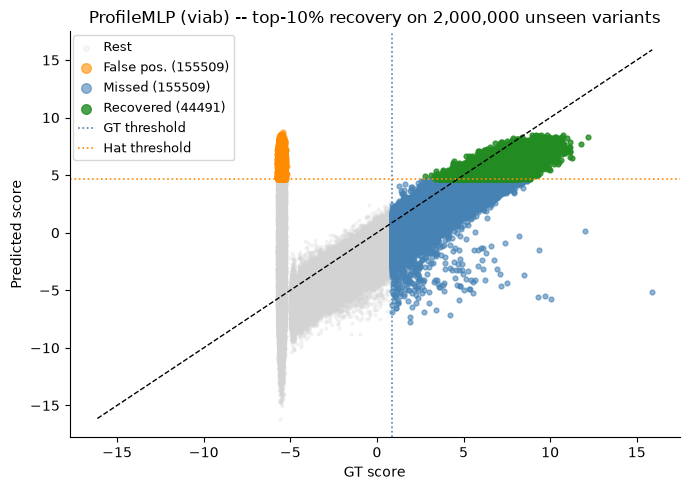


Top-k recovery on 2,000,000 unseen variants -- selectivity (target2):
  Top   1%   precision = 0.195   (random baseline = 0.010)
  Top   5%   precision = 0.207   (random baseline = 0.050)
  Top  10%   precision = 0.252   (random baseline = 0.100)
  Top  20%   precision = 0.329   (random baseline = 0.200)


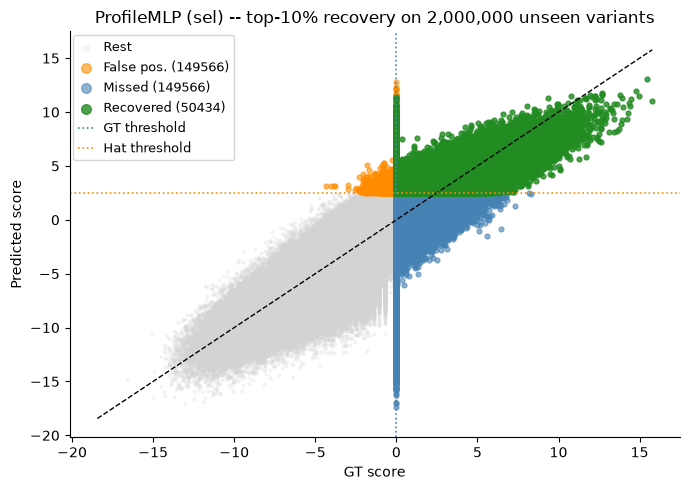

In [90]:
print(f"Top-k recovery on {len(dataset_anti2):,} unseen variants -- viability (target1):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_viab_big, pred_viab_big, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_viab_big, pred_viab_big, k_frac=0.10,
                          title=f"ProfileMLP (viab) -- top-10% recovery on {len(dataset_anti2):,} unseen variants")
plt.show()

print(f"\nTop-k recovery on {len(dataset_anti2):,} unseen variants -- selectivity (target2):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_sel_big, pred_sel_big, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_sel_big, pred_sel_big, k_frac=0.10,
                          title=f"ProfileMLP (sel) -- top-10% recovery on {len(dataset_anti2):,} unseen variants")
plt.show()

## Stratified metrics: detection-floor variants vs. the rest

`target1`/`target2` are ratios of noisy Poisson/Binomial COUNTS (`lambda1`/`lambda2`/`lambda3`)
plus the `eps` pseudocount. When a count hits exactly `0` (no capsids produced, or none
survived selection), the resulting label collapses to a value that only depends on the OTHER
count -- e.g. `target2 = log(eps / (lambda2 + eps))` whenever `lambda3 == 0`, regardless of how
bad the true selectivity score actually was. Many genuinely different sequences land on
`lambda2 == 0` or `lambda3 == 0` and therefore share (near-)identical labels (see the printed
floor fractions below). Since the MLP is trained with MSE against these labels, it has no
gradient signal to tell those sequences apart either, so it (correctly, given the data)
predicts similarly for all of them -- this is what shows up as "clumping" in the recovery
scatter plots above.

This isn't an `eps` bug -- shrinking `eps` only moves the floor value, it doesn't stop
different sequences from sharing the same small integer count. It's a real detection-limit
effect (same as a real NGS "zero reads" variant), so it's split out here rather than "fixed":
metrics computed only on the in-range (non-floor) subset show how well the model actually
ranks variants where the data contains real signal.

Top-k recovery, in-range only -- viability (target1, 420,790 variants):
  Top   1%   precision = 0.482   (random baseline = 0.010)
  Top   5%   precision = 0.715   (random baseline = 0.050)
  Top  10%   precision = 0.805   (random baseline = 0.100)
  Top  20%   precision = 0.889   (random baseline = 0.200)


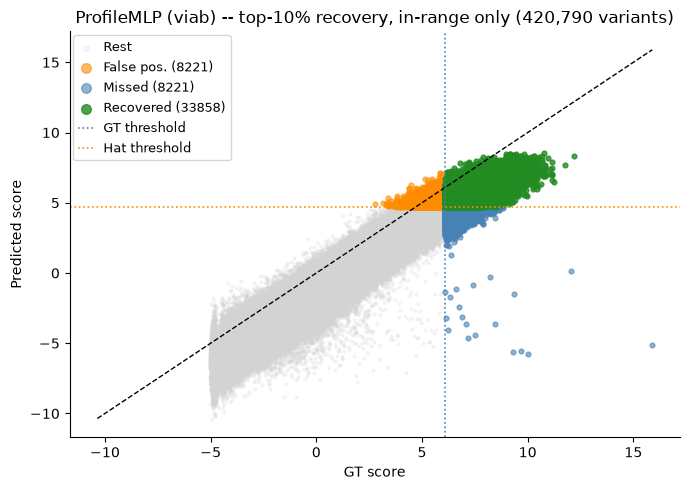


Top-k recovery, in-range only -- selectivity (target2, 311,248 variants):
  Top   1%   precision = 0.574   (random baseline = 0.010)
  Top   5%   precision = 0.671   (random baseline = 0.050)
  Top  10%   precision = 0.720   (random baseline = 0.100)
  Top  20%   precision = 0.774   (random baseline = 0.200)


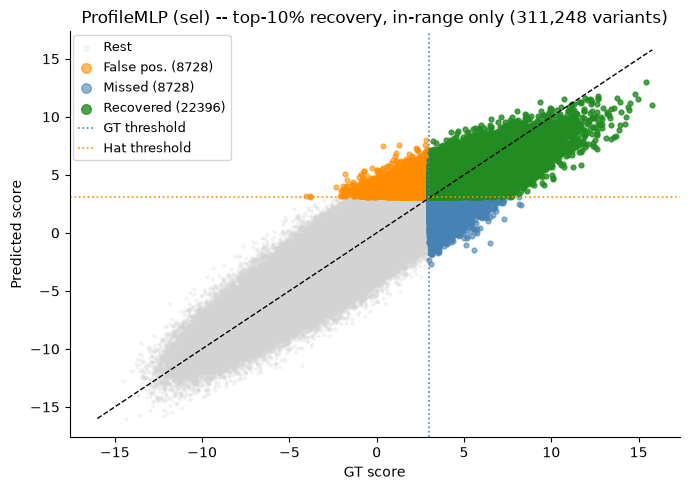

In [91]:
### Same top-10% recovery plot as before, but restricted to the in-range (non-censored)
### variants -- drops the at-floor ones (lambda2 == 0 for viab, lambda3 == 0 for sel) whose
### labels carry no real ranking information (see "Stratified metrics" discussion above).
at_floor_viab = (lambda2_big == 0)          # target1 degenerate whenever lambda2 == 0
at_floor_sel  = (lambda3_big == 0)          # target2 degenerate whenever lambda3 == 0
in_range_viab = ~at_floor_viab
in_range_sel  = ~at_floor_sel

y_viab_in_range    = y_viab_big[in_range_viab]
pred_viab_in_range = pred_viab_big[in_range_viab]
y_sel_in_range      = y_sel_big[in_range_sel]
pred_sel_in_range   = pred_sel_big[in_range_sel]

print(f"Top-k recovery, in-range only -- viability (target1, {len(y_viab_in_range):,} variants):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_viab_in_range, pred_viab_in_range, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_viab_in_range, pred_viab_in_range, k_frac=0.10,
                          title=f"ProfileMLP (viab) -- top-10% recovery, in-range only ({len(y_viab_in_range):,} variants)")
plt.show()

print(f"\nTop-k recovery, in-range only -- selectivity (target2, {len(y_sel_in_range):,} variants):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_sel_in_range, pred_sel_in_range, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_sel_in_range, pred_sel_in_range, k_frac=0.10,
                          title=f"ProfileMLP (sel) -- top-10% recovery, in-range only ({len(y_sel_in_range):,} variants)")
plt.show()

## Do the TRUE global-optimum variants get recognized by the MLP?

Everything above measured top-k recovery WITHIN a randomly-sampled pool (20,000 / 20,000,000
sequences, out of `20**7 ~= 1.28e9` possible ones) -- but the actual BEST sequences (the
global optimum of the ground-truth `F`/`J` score) are so rare in that space that they're
essentially guaranteed to never land in any such random sample. This section finds those
sequences directly -- an exhaustive brute-force scan over the full sequence space using the
EXACT `F_viab`/`J_viab` and `F_sel_anti`/`J_sel_anti` (no MLP, no sampling: `20**7` is small
enough to just score every single sequence and keep the top-k) -- then checks whether the
trained `ProfileMLP` still recognizes them as exceptional, despite never having seen them
during training.

In [92]:
def compute_score_array(seq, F, J, L=NUM_POSITIONS):
    """Same formula as Protocol.compute_score, decoupled from a Protocol instance so it can
    be applied to an arbitrary (n, L) array of raw-index sequences."""
    scores = jnp.sum(F[seq, jnp.arange(L)], axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            scores = scores + J[i, j, seq[:, i], seq[:, j]]
    return scores


@jax.jit
def _score_chunk(idx, F, J, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    return seq, compute_score_array(seq, F, J, L)


def brute_force_top_k(F, J, k=50, chunk_size=20_000_000, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """Exhaustively scores EVERY possible sequence (A**L of them) against the ground-truth F/J
    and keeps a running top-k, in chunks (so the full A**L x L array of sequences is never
    materialized at once). A**L = 20**7 ~= 1.28e9 is small enough to brute-force directly on
    GPU in a couple of seconds -- J's pairwise coupling means the optimum generally ISN'T just
    each position's best amino acid picked independently, so this can't be solved greedily."""
    total = A ** L
    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="brute-force scan"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, scores_chunk = _score_chunk(idx, F, J)

        kk = min(k, scores_chunk.shape[0])
        local_vals, local_idx = jax.lax.top_k(scores_chunk, kk)
        local_seqs = seq_chunk[local_idx]

        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    return np.asarray(best_seqs), np.asarray(best_scores)


K_BEST = 50
best_seqs_viab, best_scores_viab = brute_force_top_k(F_viab, J_viab, k=K_BEST)
best_seqs_sel,  best_scores_sel  = brute_force_top_k(F_sel_anti, J_sel_anti, k=K_BEST)

# Ground-truth score of the randomly sampled sequences (dataset_anti2), on the same scale as
# best_scores_* above (unlike y_viab_big/y_sel_big, which are noisy simulated log-enrichments).
viab_scores_sample = np.asarray(compute_score_array(jnp.asarray(seq_matrix2), F_viab, J_viab))
sel_scores_sample   = np.asarray(compute_score_array(jnp.asarray(seq_matrix2), F_sel_anti, J_sel_anti))

print(f"TRUE global-optimum viability score: {best_scores_viab[0]:.2f}  "
      f"(best of the {len(seq_matrix2):,} randomly sampled sequences: {viab_scores_sample.max():.2f})")
print(f"TRUE global-optimum selectivity score: {best_scores_sel[0]:.2f}  "
      f"(best of the {len(seq_matrix2):,} randomly sampled sequences: {sel_scores_sample.max():.2f})")

brute-force scan: 100%|██████████| 64/64 [00:01<00:00, 42.54it/s]


TRUE global-optimum viability score: 35.48  (best of the 2,000,000 randomly sampled sequences: 14.71)
TRUE global-optimum selectivity score: 19.39  (best of the 2,000,000 randomly sampled sequences: 16.89)


In [93]:
def seqs_to_strings(seq_array):
    return ["".join(AA_LABELS[a] for a in row) for row in np.asarray(seq_array)]

best_viab_strings = seqs_to_strings(best_seqs_viab)
best_sel_strings  = seqs_to_strings(best_seqs_sel)

sampled_set  = set(dataset_anti["sequence"]) | set(dataset_anti2["sequence"])
n_sampled    = len(dataset_anti) + len(dataset_anti2)
n_viab_found = sum(s in sampled_set for s in best_viab_strings)
n_sel_found  = sum(s in sampled_set for s in best_sel_strings)

print(f"Of the top-{K_BEST} TRUE-best viability variants, {n_viab_found} appear in the "
      f"{n_sampled:,}-sequence sampled pool (train + test + 200k)")
print(f"Of the top-{K_BEST} TRUE-best selectivity variants, {n_sel_found} appear in the "
      f"{n_sampled:,}-sequence sampled pool (train + test + 200k)")

Of the top-50 TRUE-best viability variants, 0 appear in the 2,020,000-sequence sampled pool (train + test + 200k)
Of the top-50 TRUE-best selectivity variants, 0 appear in the 2,020,000-sequence sampled pool (train + test + 200k)


MLP-predicted score for the TRUE #1 viability variant: -2.85  -> 35.7th percentile of the 200k-sample predicted-score distribution
MLP-predicted score for the TRUE #1 selectivity variant: 14.33  -> 100.0th percentile of the 200k-sample predicted-score distribution
Median percentile across all top-50 TRUE-best viability variants: 38.6
Median percentile across all top-50 TRUE-best selectivity variants: 100.0


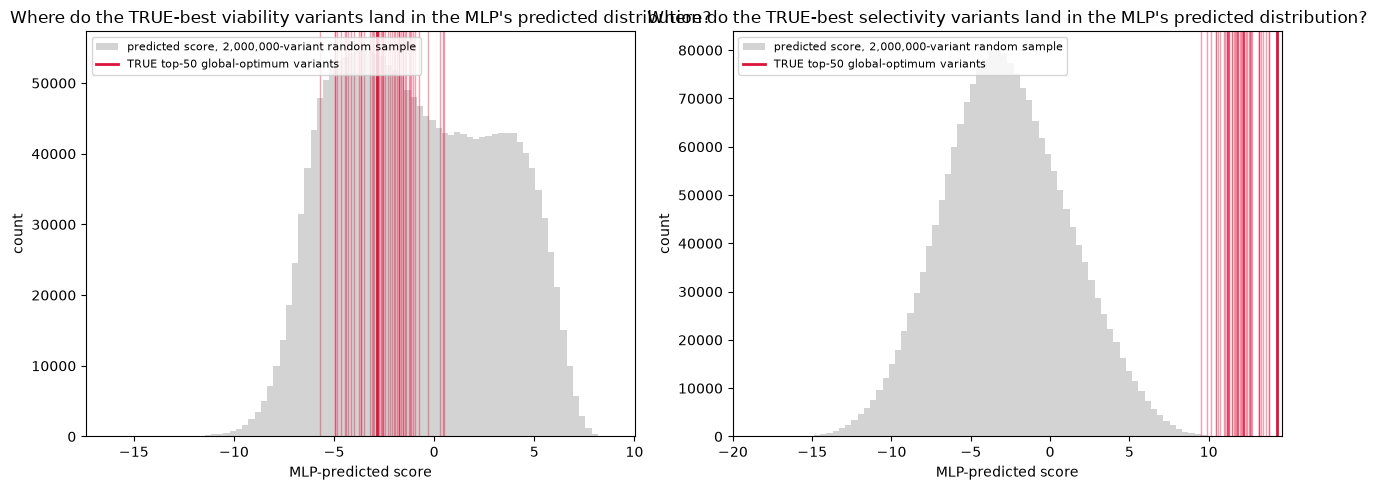

In [94]:
X_best_viab = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_viab].reshape(K_BEST, -1)
X_best_sel  = np.eye(NUM_AMINO_ACIDS, dtype=np.float32)[best_seqs_sel].reshape(K_BEST, -1)

pred_best_viab = np.asarray(predict_scores(model_viab, jnp.asarray(X_best_viab)))
pred_best_sel  = np.asarray(predict_scores(model_sel,  jnp.asarray(X_best_sel)))

pct_viab = [100 * (pred_viab_big < v).mean() for v in pred_best_viab]
pct_sel  = [100 * (pred_sel_big  < v).mean() for v in pred_best_sel]

print(f"MLP-predicted score for the TRUE #1 viability variant: {pred_best_viab[0]:.2f}  "
      f"-> {pct_viab[0]:.1f}th percentile of the 200k-sample predicted-score distribution")
print(f"MLP-predicted score for the TRUE #1 selectivity variant: {pred_best_sel[0]:.2f}  "
      f"-> {pct_sel[0]:.1f}th percentile of the 200k-sample predicted-score distribution")
print(f"Median percentile across all top-{K_BEST} TRUE-best viability variants: {np.median(pct_viab):.1f}")
print(f"Median percentile across all top-{K_BEST} TRUE-best selectivity variants: {np.median(pct_sel):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred_pop, pred_best, name in [(axes[0], pred_viab_big, pred_best_viab, "viability"),
                                       (axes[1], pred_sel_big,  pred_best_sel,  "selectivity")]:
    ax.hist(pred_pop, bins=80, color="lightgray",
            label=f"predicted score, {len(pred_pop):,}-variant random sample")
    for v in pred_best:
        ax.axvline(v, color="crimson", alpha=0.4, lw=1)
    ax.axvline(pred_best[0], color="crimson", lw=2, label=f"TRUE top-{K_BEST} global-optimum variants")
    ax.set_xlabel("MLP-predicted score")
    ax.set_ylabel("count")
    ax.set_title(f"Where do the TRUE-best {name} variants land in the MLP's predicted distribution?")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## The opposite direction: are the MLP's OWN top picks actually good?

The previous section took the TRUE best sequences and checked the MLP's opinion of them. This
flips it: scan the ENTIRE `20**7` sequence space with the trained `ProfileMLP` itself (not just
the 200k random sample it was evaluated on), find the sequences IT thinks are best, then check
their TRUE ground-truth score. This is the practically relevant question for actually using
this model to guide a search: if you asked it to propose new candidates beyond the library it
was trained on, would its favorites actually be good, or would it walk confidently into
out-of-distribution predictions that don't hold up against the real `F`/`J`?

In [95]:
@jax.jit
def _onehot_chunk(idx, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    tmp = idx
    digits = []
    for _ in range(L):
        digits.append(tmp % A)
        tmp = tmp // A
    seq = jnp.stack(digits[::-1], axis=1).astype(jnp.int32)
    seq_oh = jnp.eye(A, dtype=jnp.float32)[seq].reshape(seq.shape[0], -1)
    return seq, seq_oh


def brute_force_top_k_mlp(model, k=50, chunk_size=1_000_000, L=NUM_POSITIONS, A=NUM_AMINO_ACIDS):
    """Same exhaustive scan as brute_force_top_k, but scores every sequence with the TRAINED
    ProfileMLP instead of the ground-truth F/J -- finds the model's own favorite sequences
    across the ENTIRE space, not just the random sample it was evaluated on. Chunk size is
    smaller than brute_force_top_k's (one-hot (chunk, 140) floats vs. raw (chunk, 7) ints)."""
    total = A ** L
    best_scores = jnp.full((k,), -jnp.inf)
    best_seqs   = jnp.zeros((k, L), dtype=jnp.int32)

    for start in tqdm(range(0, total, chunk_size), desc="MLP brute-force scan"):
        end = min(start + chunk_size, total)
        idx = jnp.arange(start, end)
        seq_chunk, seq_oh_chunk = _onehot_chunk(idx)
        scores_chunk = predict_scores(model, seq_oh_chunk)

        kk = min(k, scores_chunk.shape[0])
        local_vals, local_idx = jax.lax.top_k(scores_chunk, kk)
        local_seqs = seq_chunk[local_idx]

        cand_scores = jnp.concatenate([best_scores, local_vals])
        cand_seqs   = jnp.concatenate([best_seqs, local_seqs], axis=0)
        best_scores, merge_idx = jax.lax.top_k(cand_scores, k)
        best_seqs = cand_seqs[merge_idx]

    return np.asarray(best_seqs), np.asarray(best_scores)


mlp_best_seqs_viab, mlp_best_pred_viab = brute_force_top_k_mlp(model_viab, k=K_BEST)
mlp_best_seqs_sel,  mlp_best_pred_sel  = brute_force_top_k_mlp(model_sel,  k=K_BEST)

# TRUE ground-truth score of the sequences the MLP itself thinks are best.
mlp_best_true_viab = np.asarray(compute_score_array(jnp.asarray(mlp_best_seqs_viab), F_viab, J_viab))
mlp_best_true_sel  = np.asarray(compute_score_array(jnp.asarray(mlp_best_seqs_sel), F_sel_anti, J_sel_anti))

print(f"MLP's #1 predicted-best viability variant   -- predicted={mlp_best_pred_viab[0]:.2f}, "
      f"TRUE score={mlp_best_true_viab[0]:.2f}  (TRUE global optimum: {best_scores_viab[0]:.2f})")
print(f"MLP's #1 predicted-best selectivity variant -- predicted={mlp_best_pred_sel[0]:.2f}, "
      f"TRUE score={mlp_best_true_sel[0]:.2f}  (TRUE global optimum: {best_scores_sel[0]:.2f})")

MLP brute-force scan: 100%|██████████| 1280/1280 [00:25<00:00, 49.41it/s]


MLP's #1 predicted-best viability variant   -- predicted=9.29, TRUE score=7.10  (TRUE global optimum: 35.48)
MLP's #1 predicted-best selectivity variant -- predicted=14.33, TRUE score=19.39  (TRUE global optimum: 19.39)


MLP's top-50 predicted-best viability variants   -- median TRUE-score percentile (vs. the 200k random sample): 100.0
MLP's top-50 predicted-best selectivity variants -- median TRUE-score percentile (vs. the 200k random sample): 100.0


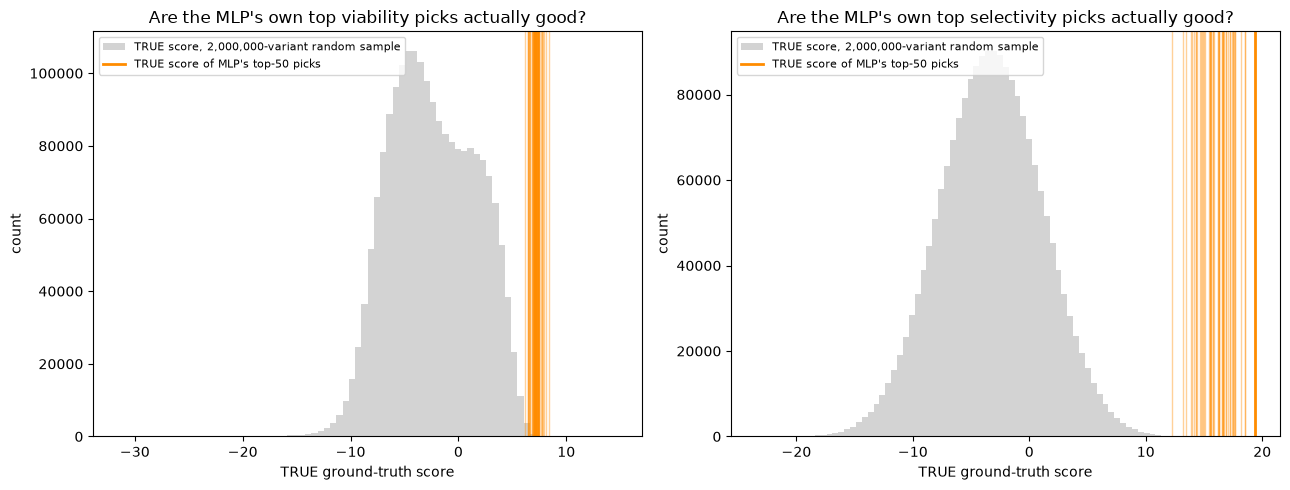

In [96]:
pct_true_viab = [100 * (viab_scores_sample < v).mean() for v in mlp_best_true_viab]
pct_true_sel  = [100 * (sel_scores_sample  < v).mean() for v in mlp_best_true_sel]

print(f"MLP's top-{K_BEST} predicted-best viability variants   -- median TRUE-score percentile "
      f"(vs. the 200k random sample): {np.median(pct_true_viab):.1f}")
print(f"MLP's top-{K_BEST} predicted-best selectivity variants -- median TRUE-score percentile "
      f"(vs. the 200k random sample): {np.median(pct_true_sel):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, true_pop, true_best, name in [(axes[0], viab_scores_sample, mlp_best_true_viab, "viability"),
                                       (axes[1], sel_scores_sample,  mlp_best_true_sel,  "selectivity")]:
    ax.hist(true_pop, bins=80, color="lightgray",
            label=f"TRUE score, {len(true_pop):,}-variant random sample")
    for v in true_best:
        ax.axvline(v, color="darkorange", alpha=0.4, lw=1)
    ax.axvline(true_best[0], color="darkorange", lw=2, label=f"TRUE score of MLP's top-{K_BEST} picks")
    ax.set_xlabel("TRUE ground-truth score")
    ax.set_ylabel("count")
    ax.set_title(f"Are the MLP's own top {name} picks actually good?")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Part 2 — Recovery using the NGS-measured `lambdap` counts (the real-experiment observable)

Everything above trained on `target1`/`target2` built from the TRUE hidden pool sizes
(`lambda1`, `lambda2`, `lambda3`) -- but a real experiment never observes those directly. The
only thing that ever gets measured is NGS reads, taken at 3 checkpoints: `lambda0p` (initial
library), `lambda2p` (post-production/viability), `lambda3p` (post-selectivity) -- see
`Protocol.loop_DE()` in `sequence_classesV1.py`. There's no `lambda1p` checkpoint (the sampled
plasmid pool right after pipetting is never sequenced), so `lambda0p` stands in as the
pre-viability baseline instead.

Same recipe as Part 1, just swapping which counts feed the log-enrichment ratio:

- `target1_p` (viability)   = `log((lambda2p + eps) / (lambda0p + eps))`
- `target2_p` (selectivity) = `log((lambda3p + eps) / (lambda2p + eps))`

Runs `protocol_anti.N_loop_DE(1)` again here (rather than reusing the `lambda0p`/`lambda2p`/
`lambda3p` globals from Part 1) so this section works regardless of what else already ran in
the kernel -- Part 1's "on another dataset" section further down reassigns those same names to
the bigger `protocol_anti2` pool, which would silently mismatch `sequences`'s length here
otherwise. Uses the same one-hot sequence encoding / train-test split from Part 1 -- only the
regression targets change.

In [97]:
rounds_p = protocol_anti.N_loop_DE(1)
bio_row_p, ngs_row_p = rounds_p[0]
lambda0p, lambda2p, lambda3p = ngs_row_p

lambda0p = np.asarray(lambda0p)
lambda2p = np.asarray(lambda2p)
lambda3p = np.asarray(lambda3p)

log_enr_viab_p = np.log((lambda2p + eps) / (lambda0p + eps))  # target1_p -- viability phase, NGS-measured
log_enr_sel_p  = np.log((lambda3p + eps) / (lambda2p + eps))  # target2_p -- selectivity phase, NGS-measured

print(f"log_enr_viab_p: min={log_enr_viab_p.min():.2f}  max={log_enr_viab_p.max():.2f}  mean={log_enr_viab_p.mean():.2f}")
print(f"log_enr_sel_p : min={log_enr_sel_p.min():.2f}  max={log_enr_sel_p.max():.2f}  mean={log_enr_sel_p.mean():.2f}")

Directed evolution rounds: 100%|██████████| 1/1 [00:00<00:00,  2.45it/s]

log_enr_viab_p: min=-11.65  max=5.89  mean=-4.70
log_enr_sel_p : min=-14.98  max=11.85  mean=-3.33


### Export to CSV (cached per experiment parameters)

Same `dataset_filename`/`build_or_load_dataset` helpers as Part 1, with a `_lambdap`-suffixed
label so this doesn't collide with the `target1`/`target2` CSV already saved above.

In [98]:
dataset_anti_p = build_or_load_dataset(protocol_anti, sequences, log_enr_viab_p, log_enr_sel_p, label="ac_lambdap")
dataset_anti_p.head()

diversity20000_Tsel1_Tviab1_noise05_ac_lambdap.csv already exists -- loading from disk


,sequence,target1,target2
0,DDTSNIP,0.878285,-9.941343
1,MSTDFNG,-0.563590,-1.150438
2,CQNSWCF,-6.629246,-4.369448
3,CRCHSEA,-10.575717,0.693147
4,QAFNMTQ,-2.857884,-1.357086


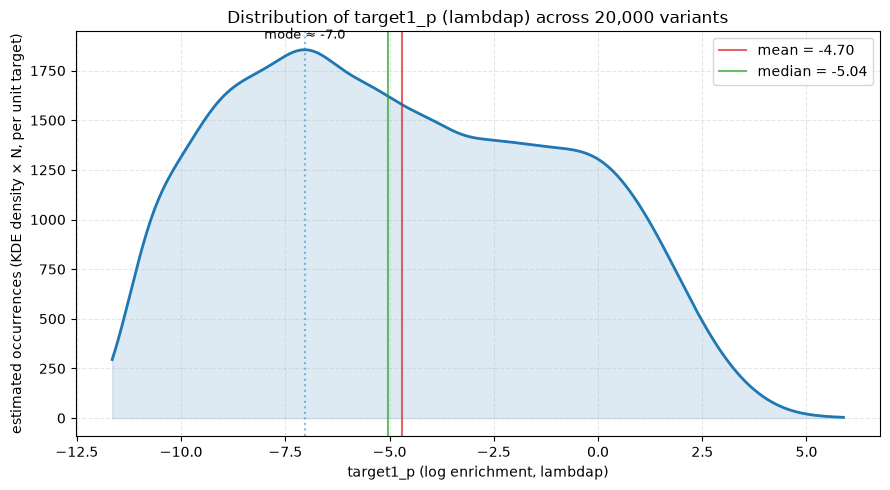

detected mode(s) at target1_p ≈ [-7.04]


In [99]:
t_viab_p = dataset_anti_p["target1"].to_numpy()

# Smooth density (Gaussian KDE), not a binned histogram -- rescaled by N so the curve reads
# as an estimated occurrence count per unit of target (area under the curve over a range ~=
# expected number of variants in that range), rather than a probability density.
grid = np.linspace(t_viab_p.min(), t_viab_p.max(), 1000)
kde = gaussian_kde(t_viab_p, bw_method=0.15)
occurrences = kde(grid) * len(t_viab_p)

# Auto-detect modes (and, if bimodal, the valley between them) instead of eyeballing the plot.
peaks, _ = find_peaks(occurrences, prominence=occurrences.max() * 0.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grid, occurrences, color="tab:blue", lw=2)
ax.fill_between(grid, occurrences, alpha=0.15, color="tab:blue")

for p in peaks:
    ax.axvline(grid[p], color="tab:blue", linestyle=":", alpha=0.5)
    ax.annotate(f"mode ≈ {grid[p]:.1f}", (grid[p], occurrences[p]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

if len(peaks) >= 2:
    lo, hi = peaks[0], peaks[-1]
    valley = lo + np.argmin(occurrences[lo:hi + 1])
    ax.axvline(grid[valley], color="gray", linestyle="--", alpha=0.6)
    ax.annotate(f"valley ≈ {grid[valley]:.1f}", (grid[valley], occurrences[valley]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="gray")

ax.axvline(t_viab_p.mean(), color="tab:red", linestyle="-", alpha=0.7, label=f"mean = {t_viab_p.mean():.2f}")
ax.axvline(np.median(t_viab_p), color="tab:green", linestyle="-", alpha=0.7, label=f"median = {np.median(t_viab_p):.2f}")

ax.set_xlabel("target1_p (log enrichment, lambdap)")
ax.set_ylabel("estimated occurrences (KDE density × N, per unit target)")
ax.set_title(f"Distribution of target1_p (lambdap) across {len(t_viab_p):,} variants")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"detected mode(s) at target1_p ≈ {np.round(grid[peaks], 2)}")

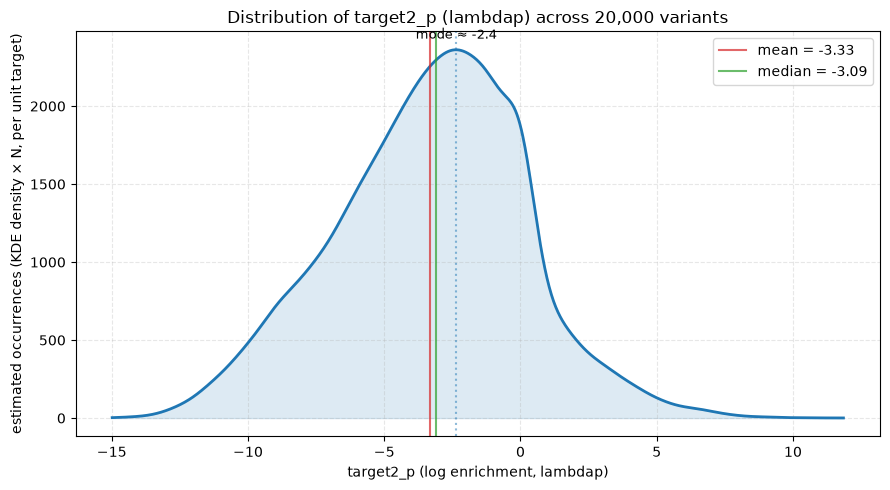

detected mode(s) at target2_p ≈ [-2.36]


In [100]:
t_sel_p = dataset_anti_p["target2"].to_numpy()

# Smooth density (Gaussian KDE), not a binned histogram -- rescaled by N so the curve reads
# as an estimated occurrence count per unit of target (area under the curve over a range ~=
# expected number of variants in that range), rather than a probability density.
grid = np.linspace(t_sel_p.min(), t_sel_p.max(), 1000)
kde = gaussian_kde(t_sel_p, bw_method=0.15)
occurrences = kde(grid) * len(t_sel_p)

# Auto-detect modes (and, if bimodal, the valley between them) instead of eyeballing the plot.
peaks, _ = find_peaks(occurrences, prominence=occurrences.max() * 0.05)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grid, occurrences, color="tab:blue", lw=2)
ax.fill_between(grid, occurrences, alpha=0.15, color="tab:blue")

for p in peaks:
    ax.axvline(grid[p], color="tab:blue", linestyle=":", alpha=0.5)
    ax.annotate(f"mode ≈ {grid[p]:.1f}", (grid[p], occurrences[p]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

if len(peaks) >= 2:
    lo, hi = peaks[0], peaks[-1]
    valley = lo + np.argmin(occurrences[lo:hi + 1])
    ax.axvline(grid[valley], color="gray", linestyle="--", alpha=0.6)
    ax.annotate(f"valley ≈ {grid[valley]:.1f}", (grid[valley], occurrences[valley]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9, color="gray")

ax.axvline(t_sel_p.mean(), color="tab:red", linestyle="-", alpha=0.7, label=f"mean = {t_sel_p.mean():.2f}")
ax.axvline(np.median(t_sel_p), color="tab:green", linestyle="-", alpha=0.7, label=f"median = {np.median(t_sel_p):.2f}")

ax.set_xlabel("target2_p (log enrichment, lambdap)")
ax.set_ylabel("estimated occurrences (KDE density × N, per unit target)")
ax.set_title(f"Distribution of target2_p (lambdap) across {len(t_sel_p):,} variants")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"detected mode(s) at target2_p ≈ {np.round(grid[peaks], 2)}")

### ProfileMLP recovery (lambdap): predicting log-enrichment from sequence, retrieving F

Same `ProfileMLP` + `train_profile_mlp` recipe as Part 1, reusing the same one-hot encoding and
train/test split (`X_train_full`, `X_test`, `idx_train`, `idx_test`, built from `sequences` in
Part 1) -- only the regression targets change, to `target1_p`/`target2_p`.

In [101]:
y_viab_all_p = dataset_anti_p["target1"].to_numpy()
y_viab_train_p, y_viab_test_p = y_viab_all_p[idx_train], y_viab_all_p[idx_test]
Xtr_viab_p, ytr_viab_p, Xva_viab_p, yva_viab_p = split_train_val(X_train_full, y_viab_train_p, val_frac=0.15, seed=0)
print(f"ProfileMLP (viab, lambdap) -- train: {len(Xtr_viab_p):,}  val: {len(Xva_viab_p):,}  test: {len(X_test):,}")

model_viab_p, hist_viab_p = train_profile_mlp(Xtr_viab_p, ytr_viab_p, Xva_viab_p, yva_viab_p, seed=0)

ProfileMLP (viab, lambdap) -- train: 8,500  val: 1,500  test: 10,000


Training ProfileMLP:  62%|██████▏   | 185/300 [00:02<00:01, 63.90it/s]

Early stopping at epoch 185 (best val MSE=1.0166)


In [102]:
y_sel_all_p = dataset_anti_p["target2"].to_numpy()
y_sel_train_p, y_sel_test_p = y_sel_all_p[idx_train], y_sel_all_p[idx_test]
Xtr_sel_p, ytr_sel_p, Xva_sel_p, yva_sel_p = split_train_val(X_train_full, y_sel_train_p, val_frac=0.15, seed=1)
print(f"ProfileMLP (sel, lambdap) -- train: {len(Xtr_sel_p):,}  val: {len(Xva_sel_p):,}  test: {len(X_test):,}")

model_sel_p, hist_sel_p = train_profile_mlp(Xtr_sel_p, ytr_sel_p, Xva_sel_p, yva_sel_p, seed=1)

ProfileMLP (sel, lambdap) -- train: 8,500  val: 1,500  test: 10,000


Training ProfileMLP:  33%|███▎      | 99/300 [00:01<00:03, 51.06it/s]

Early stopping at epoch 99 (best val MSE=2.0855)


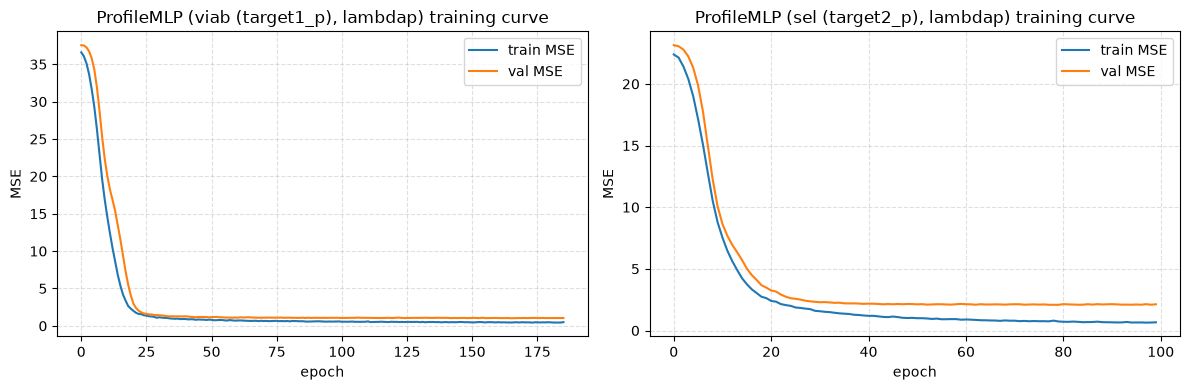

target1_p (viab) -- Pearson r (test): 0.9653
target2_p (sel)  -- Pearson r (test): 0.9004


In [103]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, name in [(axes[0], hist_viab_p, "viab (target1_p)"), (axes[1], hist_sel_p, "sel (target2_p)")]:
    ax.plot(hist["train_loss"], label="train MSE")
    ax.plot(hist["val_loss"],   label="val MSE")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
    ax.set_title(f"ProfileMLP ({name}, lambdap) training curve")
    ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

pred_viab_test_p = np.asarray(predict_scores(model_viab_p, jnp.asarray(X_test)))
pred_sel_test_p  = np.asarray(predict_scores(model_sel_p,  jnp.asarray(X_test)))

print(f"target1_p (viab) -- Pearson r (test): {pearson(y_viab_test_p, pred_viab_test_p):.4f}")
print(f"target2_p (sel)  -- Pearson r (test): {pearson(y_sel_test_p,  pred_sel_test_p):.4f}")

In [104]:
F_viab_hat_p = extract_effective_F(model_viab_p, backgrounds)
F_sel_hat_p  = extract_effective_F(model_sel_p,  backgrounds)

print(f"F_viab_hat_p shape: {F_viab_hat_p.shape}  F_sel_hat_p shape: {F_sel_hat_p.shape}")

F_viab_hat_p shape: (20, 7)  F_sel_hat_p shape: (20, 7)


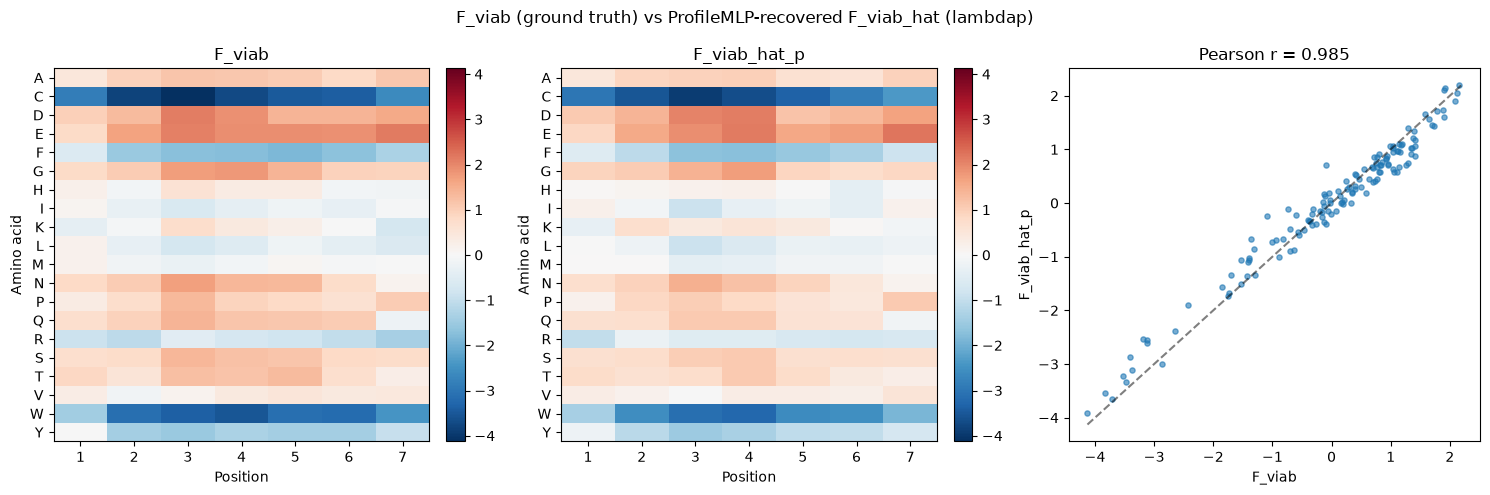

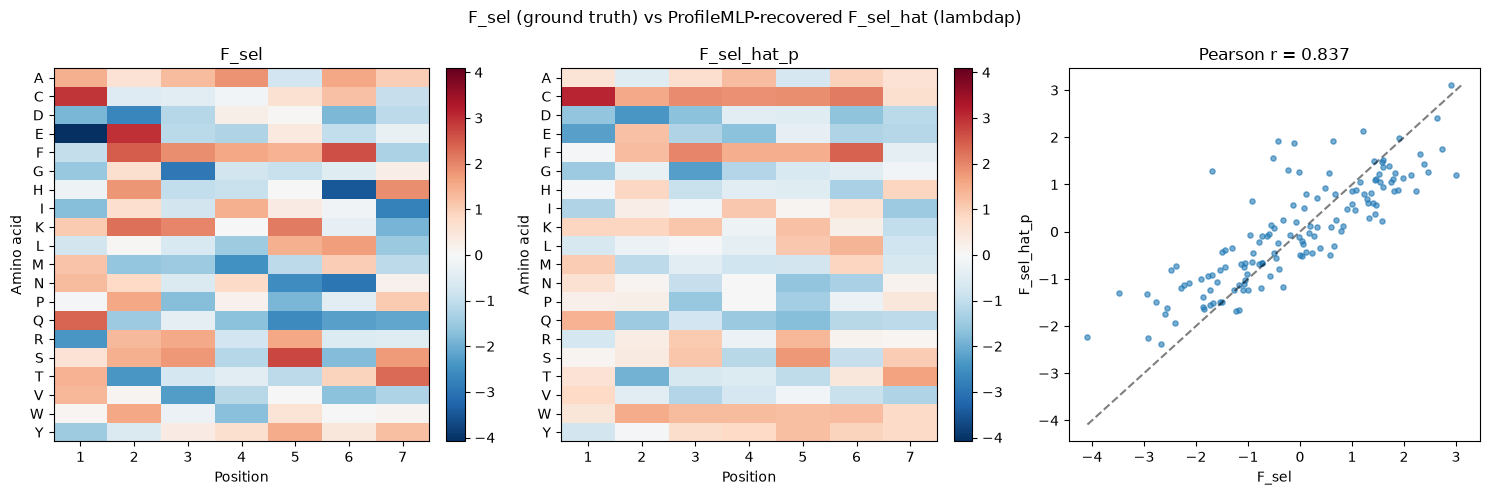

In [105]:
compare_F(F_viab, F_viab_hat_p, "F_viab (ground truth) vs ProfileMLP-recovered F_viab_hat (lambdap)",
          label_a="F_viab", label_b="F_viab_hat_p")
compare_F(F_sel_anti, F_sel_hat_p, "F_sel (ground truth) vs ProfileMLP-recovered F_sel_hat (lambdap)",
          label_a="F_sel", label_b="F_sel_hat_p")

### How well are the best variants predicted? (held-out top-k recovery, lambdap)

Held-out (test) top-k recovery -- viability (target1_p, lambdap):
  Top   1%   precision = 0.510   (random baseline = 0.010)
  Top   5%   precision = 0.698   (random baseline = 0.050)
  Top  10%   precision = 0.784   (random baseline = 0.100)
  Top  20%   precision = 0.870   (random baseline = 0.200)


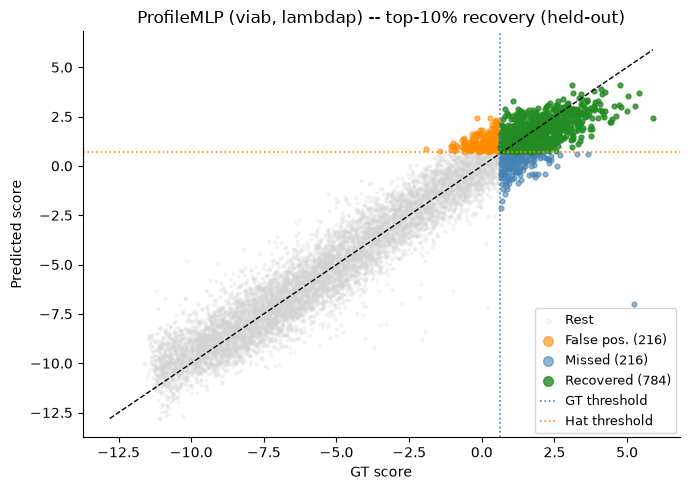


Held-out (test) top-k recovery -- selectivity (target2_p, lambdap):
  Top   1%   precision = 0.500   (random baseline = 0.010)
  Top   5%   precision = 0.632   (random baseline = 0.050)
  Top  10%   precision = 0.673   (random baseline = 0.100)
  Top  20%   precision = 0.696   (random baseline = 0.200)


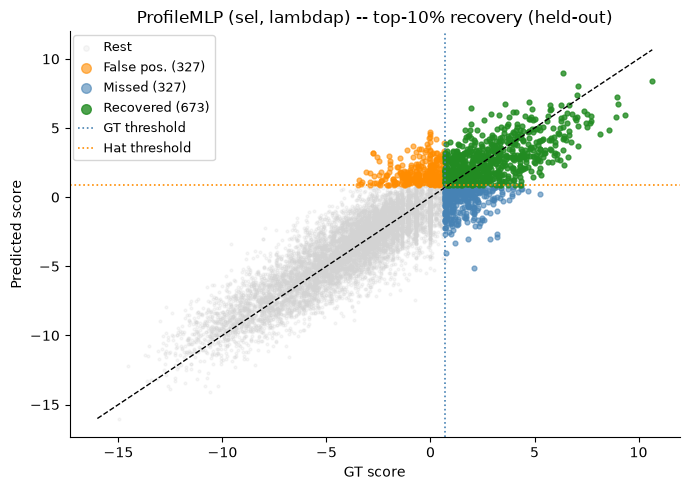

In [106]:
print("Held-out (test) top-k recovery -- viability (target1_p, lambdap):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_viab_test_p, pred_viab_test_p, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_viab_test_p, pred_viab_test_p, k_frac=0.10,
                          title="ProfileMLP (viab, lambdap) -- top-10% recovery (held-out)")
plt.show()

print("\nHeld-out (test) top-k recovery -- selectivity (target2_p, lambdap):")
for frac in [0.01, 0.05, 0.10, 0.20]:
    p = precision_at_k(y_sel_test_p, pred_sel_test_p, k_frac=frac)
    print(f"  Top {int(frac * 100):3d}%   precision = {p:.3f}   (random baseline = {frac:.3f})")

fig = plot_topk_recovery(y_sel_test_p, pred_sel_test_p, k_frac=0.10,
                          title="ProfileMLP (sel, lambdap) -- top-10% recovery (held-out)")
plt.show()

## Do the TRUE global-optimum variants get recognized by the MLP? (lambdap)

Same question as the ground-truth-lambda section above, now for the models trained on the
NGS-measured `lambdap` targets: does `model_viab_p`/`model_sel_p` still recognize the TRUE
global-optimum sequences as exceptional? Reuses `best_seqs_viab`/`best_seqs_sel` (the
brute-force result against the exact `F`/`J`, which doesn't depend on any trained model) and
`X_big` (the one-hot encoding of the big sampled pool) from Part 1 -- only the model doing the
scoring changes.

MLP-predicted score (lambdap) for the TRUE #1 viability variant: -9.66  -> 7.3th percentile of the 2,000,000-sample predicted-score distribution
MLP-predicted score (lambdap) for the TRUE #1 selectivity variant: 11.12  -> 100.0th percentile of the 2,000,000-sample predicted-score distribution
Median percentile across all top-50 TRUE-best viability variants (lambdap): 16.1
Median percentile across all top-50 TRUE-best selectivity variants (lambdap): 100.0


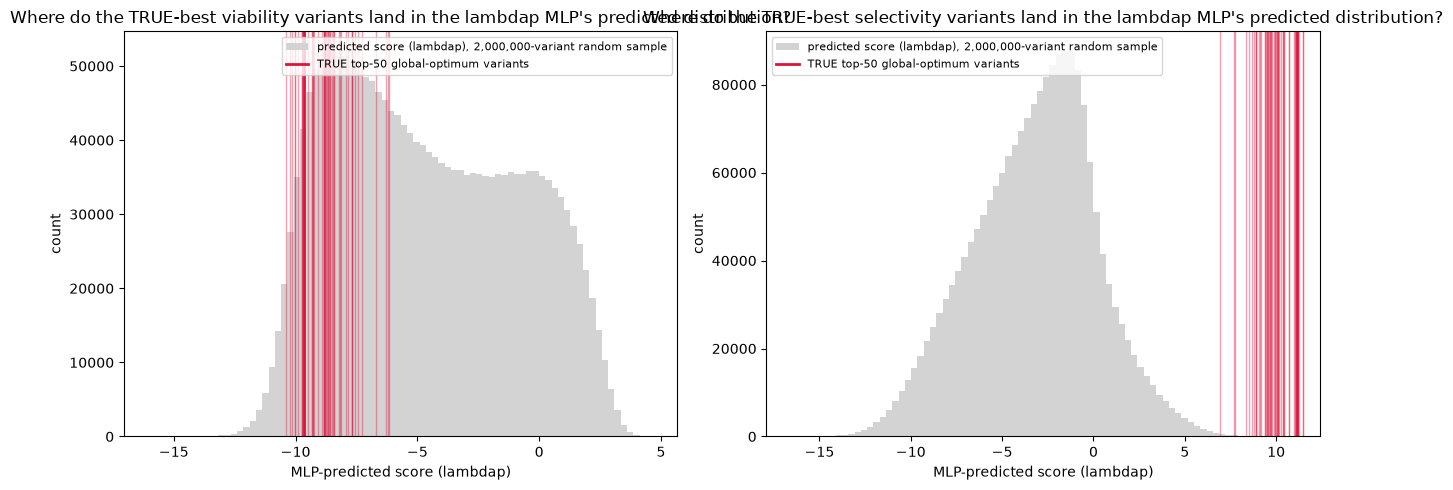

In [107]:
pred_viab_big_p = np.asarray(predict_scores(model_viab_p, jnp.asarray(X_big)))
pred_sel_big_p  = np.asarray(predict_scores(model_sel_p,  jnp.asarray(X_big)))

pred_best_viab_p = np.asarray(predict_scores(model_viab_p, jnp.asarray(X_best_viab)))
pred_best_sel_p  = np.asarray(predict_scores(model_sel_p,  jnp.asarray(X_best_sel)))

pct_viab_p = [100 * (pred_viab_big_p < v).mean() for v in pred_best_viab_p]
pct_sel_p  = [100 * (pred_sel_big_p  < v).mean() for v in pred_best_sel_p]

print(f"MLP-predicted score (lambdap) for the TRUE #1 viability variant: {pred_best_viab_p[0]:.2f}  "
      f"-> {pct_viab_p[0]:.1f}th percentile of the {len(pred_viab_big_p):,}-sample predicted-score distribution")
print(f"MLP-predicted score (lambdap) for the TRUE #1 selectivity variant: {pred_best_sel_p[0]:.2f}  "
      f"-> {pct_sel_p[0]:.1f}th percentile of the {len(pred_sel_big_p):,}-sample predicted-score distribution")
print(f"Median percentile across all top-{K_BEST} TRUE-best viability variants (lambdap): {np.median(pct_viab_p):.1f}")
print(f"Median percentile across all top-{K_BEST} TRUE-best selectivity variants (lambdap): {np.median(pct_sel_p):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred_pop, pred_best, name in [(axes[0], pred_viab_big_p, pred_best_viab_p, "viability"),
                                       (axes[1], pred_sel_big_p,  pred_best_sel_p,  "selectivity")]:
    ax.hist(pred_pop, bins=80, color="lightgray",
            label=f"predicted score (lambdap), {len(pred_pop):,}-variant random sample")
    for v in pred_best:
        ax.axvline(v, color="crimson", alpha=0.4, lw=1)
    ax.axvline(pred_best[0], color="crimson", lw=2, label=f"TRUE top-{K_BEST} global-optimum variants")
    ax.set_xlabel("MLP-predicted score (lambdap)")
    ax.set_ylabel("count")
    ax.set_title(f"Where do the TRUE-best {name} variants land in the lambdap MLP's predicted distribution?")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## The opposite direction: are the lambdap MLP's OWN top picks actually good?

Same flip as the ground-truth-lambda section above: scan the ENTIRE `20**7` sequence space with
`model_viab_p`/`model_sel_p` itself, find the sequences IT thinks are best, then check their
TRUE ground-truth score. Reuses `brute_force_top_k_mlp` and `compute_score_array` (both defined
above, model-agnostic).

In [108]:
mlp_best_seqs_viab_p, mlp_best_pred_viab_p = brute_force_top_k_mlp(model_viab_p, k=K_BEST)
mlp_best_seqs_sel_p,  mlp_best_pred_sel_p  = brute_force_top_k_mlp(model_sel_p,  k=K_BEST)

# TRUE ground-truth score of the sequences the lambdap MLP itself thinks are best.
mlp_best_true_viab_p = np.asarray(compute_score_array(jnp.asarray(mlp_best_seqs_viab_p), F_viab, J_viab))
mlp_best_true_sel_p  = np.asarray(compute_score_array(jnp.asarray(mlp_best_seqs_sel_p), F_sel_anti, J_sel_anti))

print(f"lambdap MLP's #1 predicted-best viability variant   -- predicted={mlp_best_pred_viab_p[0]:.2f}, "
      f"TRUE score={mlp_best_true_viab_p[0]:.2f}  (TRUE global optimum: {best_scores_viab[0]:.2f})")
print(f"lambdap MLP's #1 predicted-best selectivity variant -- predicted={mlp_best_pred_sel_p[0]:.2f}, "
      f"TRUE score={mlp_best_true_sel_p[0]:.2f}  (TRUE global optimum: {best_scores_sel[0]:.2f})")

MLP brute-force scan: 100%|██████████| 1280/1280 [00:26<00:00, 49.14it/s]


lambdap MLP's #1 predicted-best viability variant   -- predicted=4.98, TRUE score=7.94  (TRUE global optimum: 35.48)
lambdap MLP's #1 predicted-best selectivity variant -- predicted=11.94, TRUE score=16.37  (TRUE global optimum: 19.39)


lambdap MLP's top-50 predicted-best viability variants   -- median TRUE-score percentile (vs. the 2,000,000 random sample): 100.0
lambdap MLP's top-50 predicted-best selectivity variants -- median TRUE-score percentile (vs. the 2,000,000 random sample): 100.0


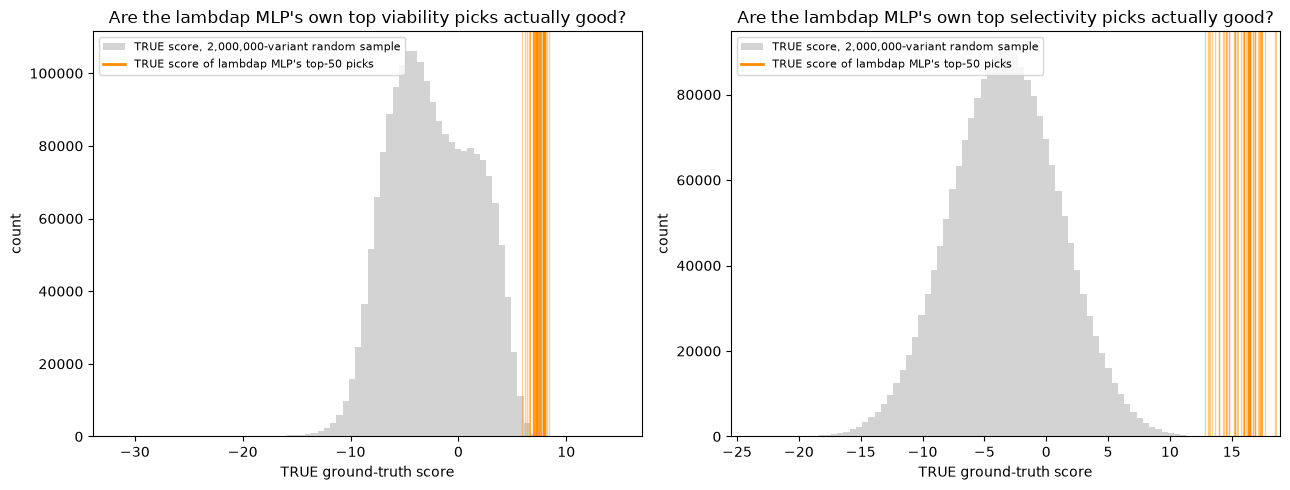

In [109]:
pct_true_viab_p = [100 * (viab_scores_sample < v).mean() for v in mlp_best_true_viab_p]
pct_true_sel_p  = [100 * (sel_scores_sample  < v).mean() for v in mlp_best_true_sel_p]

print(f"lambdap MLP's top-{K_BEST} predicted-best viability variants   -- median TRUE-score percentile "
      f"(vs. the {len(viab_scores_sample):,} random sample): {np.median(pct_true_viab_p):.1f}")
print(f"lambdap MLP's top-{K_BEST} predicted-best selectivity variants -- median TRUE-score percentile "
      f"(vs. the {len(sel_scores_sample):,} random sample): {np.median(pct_true_sel_p):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, true_pop, true_best, name in [(axes[0], viab_scores_sample, mlp_best_true_viab_p, "viability"),
                                       (axes[1], sel_scores_sample,  mlp_best_true_sel_p,  "selectivity")]:
    ax.hist(true_pop, bins=80, color="lightgray",
            label=f"TRUE score, {len(true_pop):,}-variant random sample")
    for v in true_best:
        ax.axvline(v, color="darkorange", alpha=0.4, lw=1)
    ax.axvline(true_best[0], color="darkorange", lw=2, label=f"TRUE score of lambdap MLP's top-{K_BEST} picks")
    ax.set_xlabel("TRUE ground-truth score")
    ax.set_ylabel("count")
    ax.set_title(f"Are the lambdap MLP's own top {name} picks actually good?")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()